# REPSOL DATATHON - FURA RENEWAL


# Project Details

This project addresses a key challenge in Spain’s energy transition: the underutilization of renewable energy due to its intermittent nature and the lack of storage or alignment with demand. The focus is on an industrial facility equipped with a 175 kWp solar installation, without grid feed-in. The primary goal is to quantify the amount of solar energy lost between July 2023 and August 2024 due to inefficiencies, particularly during low-demand periods such as weekends.

The first objective is to forecast the plant’s maximum potential solar generation using historical and meteorological data, and then compare it with actual consumption to assess underutilization. The second objective involves simulating the use of a hypothetical 100 kWh battery to store surplus solar energy and discharge it during periods of high demand or high carbon intensity. This aims to maximize self-consumption (Ra) and reduce CO₂ emissions by September 2024.

The datasets utilized in this project include: 

1.	Photovoltaic Generation- captures electricity generated by solar photovoltaic.
2.	Energy Consumed from the Grid- contains amount of energy consumed from grid 
3.	Meteorological Data- This dataset includes key meteorological variables 
4.	Carbon Intensity-  Carbon emissions associated with electricity consumption 
5.	Actual Photovoltaic Energy Consumption- actual usage of the energy 
6.	Battery Optimization- contains a conceptual demonstration of how to perform charging and discharging operations for a theoretical battery system.


# 1. Exploratory Data Analysis - Understanding the Data

### 1.1. Importing Required Libraries

In [1]:
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 
import math

from sklearn.preprocessing import StandardScaler

import itertools
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import plotly.graph_objects as go


### 1.2. Read the data files

In [2]:
# energy generation and weather data
generation_df = pd.read_csv('data/repsol_data/Generacion_fotovoltaica.csv')
met_df = pd.read_excel('data/repsol_data/Meteorologia.xlsx')

# Total energy consumed from the power grid (in kWh)
consumption_df = pd.read_csv('data/repsol_data/Consumo.csv')

# Total energy consumption from plant in september
sept_total_consumption_df = pd.read_csv('data/repsol_data/Consumo_sept.csv')

# Consumption from solar
sept_solar_consumption_df = pd.read_csv('data/repsol_data/Consumo_fotovoltaica.csv')


Here we define a few functions that we will use to check the data sets

In [3]:
# Define function to check dataframe structure
def dataframe_check(dfs):
    for name, df in dfs:
        print(f"Dataset: {name} \n")
        print(f"Number of rows and columns: {df.shape} \n")
        print("Variables information:\n")
        print(df.info())
        print("\n")


# Define a function to convert the 'FECHA' column to datetime
def convert_to_datetime(df, column_name='FECHA'):
    df[column_name] = pd.to_datetime(df[column_name])


In [4]:
# List of dataframes and their corresponding column names
dataframes_to_convert = [
    (generation_df, 'FECHA'),
    (consumption_df, 'FECHA'),
    (sept_solar_consumption_df, 'FECHA'),
    (sept_total_consumption_df, 'FECHA')
]

# Loop through the list and apply the function
for df, column_name in dataframes_to_convert:
    convert_to_datetime(df, column_name=column_name)

In [5]:
dataframe_list = [
    ("generation_df", generation_df),
    ("consumption_df", consumption_df),
    ("solar_consumption_df", sept_solar_consumption_df),
    ("met_df", met_df),
    ("sept_2024_consumption_df", sept_total_consumption_df )
    ]

dataframe_check(dataframe_list)

Dataset: generation_df 

Number of rows and columns: (9708, 2) 

Variables information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9708 entries, 0 to 9707
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   FECHA              9708 non-null   datetime64[ns]
 1   TOTAL_KWH_ENERGIA  8544 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 151.8 KB
None


Dataset: consumption_df 

Number of rows and columns: (9708, 2) 

Variables information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9708 entries, 0 to 9707
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   FECHA              9708 non-null   datetime64[ns]
 1   TOTAL_KWH_ENERGIA  9694 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 151.8 KB
None


Dataset: solar_consumption_df 

N

### 1.3 Visualizing Generation and Consumption

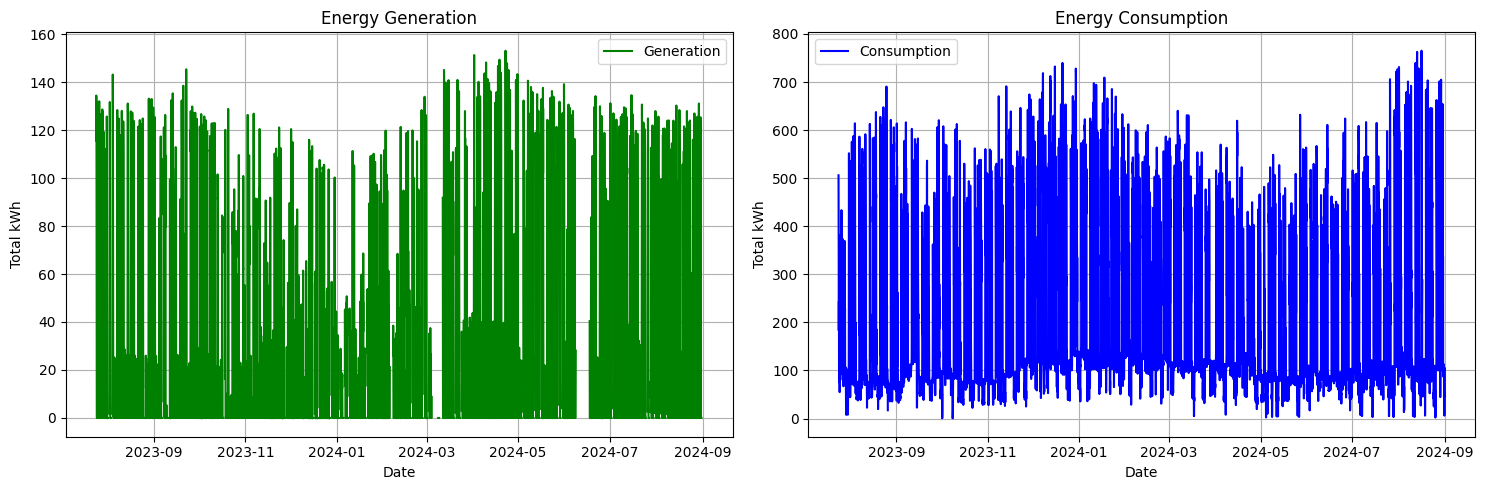

In [6]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot generation_df
axes[0].plot(generation_df['FECHA'], generation_df['TOTAL_KWH_ENERGIA'], label='Generation', color='green')
axes[0].set_title('Energy Generation')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total kWh')
axes[0].legend()
axes[0].grid()

# Plot consumption_df
axes[1].plot(consumption_df['FECHA'], consumption_df['TOTAL_KWH_ENERGIA'], label='Consumption', color='blue')
axes[1].set_title('Energy Consumption')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total kWh')
axes[1].legend()
axes[1].grid()

# Adjust layout
plt.tight_layout()
plt.show()

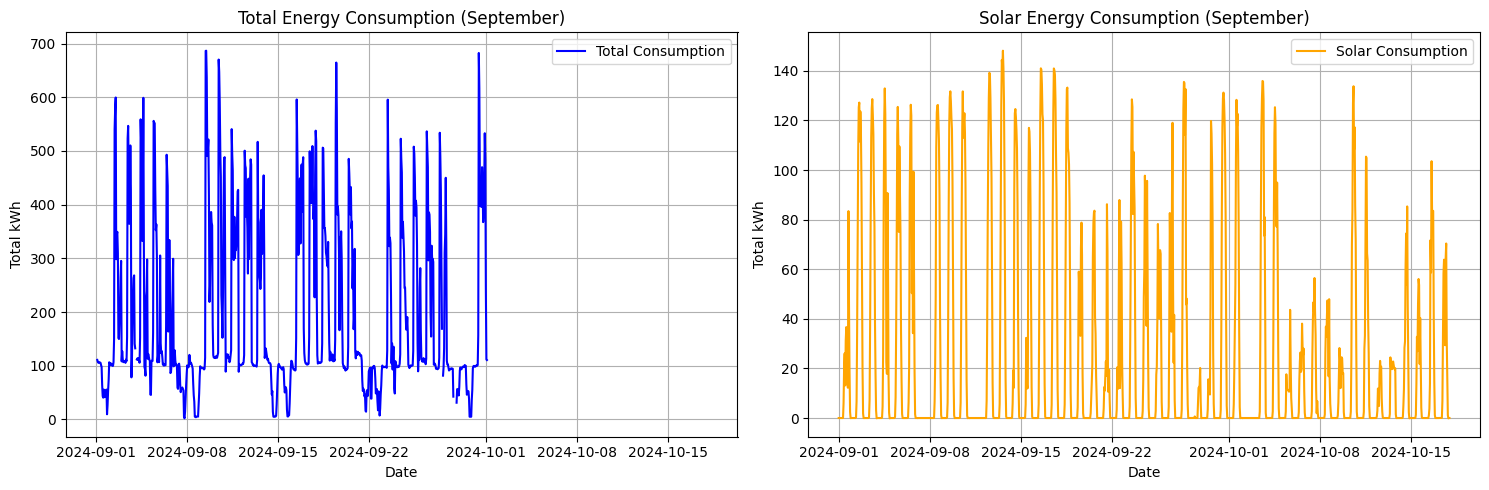

In [7]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot sept_total_consumption_df
axes[0].plot(sept_total_consumption_df['FECHA'], sept_total_consumption_df['TOTAL_KWH_ENERGIA'], label='Total Consumption', color='blue')
axes[0].set_title('Total Energy Consumption (September)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Total kWh')
axes[0].legend()
axes[0].grid()

# Plot sept_solar_consumption_df
axes[1].plot(sept_solar_consumption_df['FECHA'], sept_solar_consumption_df['TOTAL_KWH_ENERGIA'], label='Solar Consumption', color='orange')
axes[1].set_title('Solar Energy Consumption (September)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Total kWh')
axes[1].legend()
axes[1].grid()

# Adjust layout
plt.tight_layout()
plt.show()

### 1.4 Meteorological Data - Cleaning
The meteorologia.xlsx file has all its data in 1 column, separated by commas like a csv file. To make it readable:

1. We separate the data into respective columns
2. Create separate dataframes for each meteorological station
3. Merge this dataframes back based on timestamp so as to align this with generation and consumption data.

For analysis later, dimension reduction will be required.

In [8]:
met_df.head(2)

,"FORECAST_TIMESTAMP,LATITUDE,LONGITUDE,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,msletmeanSea_0,presheightAboveGround_80,pwatatmosphereSingleLayer_0,qheightAboveGround_80,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80"
0,"2023-07-24 11:00:00+00:00,40.0,-4.0,6.98971679..."
1,"2023-07-24 12:00:00+00:00,40.0,-4.0,7.52635742..."


Spliting the data into individual columns

In [9]:
# Split data into individual columns
df = met_df[met_df.columns[0]].str.split(',', expand=True)
df.columns = met_df.columns[0].split(',')

# Rename timestamp column to FECHA to match other datasets
df = df.rename(columns={'FORECAST_TIMESTAMP': 'FECHA'})

df.head(2)


,FECHA,LATITUDE,LONGITUDE,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
0,2023-07-24 11:00:00+00:00,40.0,-4.0,6.989716796875,1.524462890625,19.6,0.005070170713195802,301.66785888671876,18000.0,300.24403076171876,...,95095.85312500001,0.8,298.878662109375,301.63212890625,291.7014892578125,324.00639648437505,0.0,316.1000122070313,7.9791015625,1.76345703125
1,2023-07-24 12:00:00+00:00,40.0,-4.0,7.526357421875,1.301796875,18.400000000000002,0.005260486483306886,303.36557617187503,21600.0,301.47092285156253,...,95033.79375000001,1.7000000000000002,300.5,303.3634521484375,291.7014892578125,325.803369140625,0.0,318.70000000000005,8.8016748046875,1.62306640625


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100557 entries, 0 to 100556
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   FECHA                         100557 non-null  object
 1   LATITUDE                      100557 non-null  object
 2   LONGITUDE                     100557 non-null  object
 3   10uheightAboveGround_10       100557 non-null  object
 4   10vheightAboveGround_10       100557 non-null  object
 5   2rheightAboveGround_2         100557 non-null  object
 6   2shheightAboveGround_2        100557 non-null  object
 7   2theightAboveGround_2         100557 non-null  object
 8   SUNSDsurface_0                100557 non-null  object
 9   aptmpheightAboveGround_2      100557 non-null  object
 10  dlwrfsurface_0                100557 non-null  object
 11  dswrfsurface_0                100557 non-null  object
 12  gustsurface_0                 100557 non-null  object
 13 

Checking for null values

In [11]:
df.isna().sum()

FECHA                           0
LATITUDE                        0
LONGITUDE                       0
10uheightAboveGround_10         0
10vheightAboveGround_10         0
2rheightAboveGround_2           0
2shheightAboveGround_2          0
2theightAboveGround_2           0
SUNSDsurface_0                  0
aptmpheightAboveGround_2        0
dlwrfsurface_0                  0
dswrfsurface_0                  0
gustsurface_0                   0
msletmeanSea_0                  0
presheightAboveGround_80        0
pwatatmosphereSingleLayer_0     0
qheightAboveGround_80           0
spsurface_0                     0
tccatmosphere_0                 0
theightAboveGround_80           0
tmaxheightAboveGround_2         0
tminheightAboveGround_2         0
tozneatmosphereSingleLayer_0    0
tpsurface_0                     0
tsurface_0                      0
uheightAboveGround_80           0
vheightAboveGround_80           0
dtype: int64

Convert variables to matching datatypes

In [12]:
# Convert FECHA to datetime
convert_to_datetime(df)

# Remove UTC from the FECHA column
df['FECHA'] = df['FECHA'].dt.tz_localize(None)

# Convert all other columns to numeric

cols_to_convert = df.columns[1:]  
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')



Map weather data to a meteorological station location

In [13]:
# Get unique latitude-longitude pairs
unique_points = df[['LATITUDE', 'LONGITUDE']].drop_duplicates()
print(unique_points)

       LATITUDE  LONGITUDE
0         40.00      -4.00
11173     40.00      -3.75
22346     40.00      -3.50
33519     40.25      -4.00
44692     40.25      -3.75
55865     40.25      -3.50
67038     40.50      -4.00
78211     40.50      -3.75
89384     40.50      -3.50


In [14]:
# Met location mapping based on unique coordinates

met_location_coordinates = {
    (40.0, -4.0): 'met_point_1',
    (40.0, -3.75): 'met_point_2',
    (40.0, -3.5): 'met_point_3',
    (40.25, -4.0): 'met_point_4',
    (40.25, -3.75): 'met_point_5',
    (40.25, -3.5): 'met_point_6',
    (40.5, -4.0): 'met_point_7',
    (40.5, -3.75): 'met_point_8',
    (40.5, -3.5): 'met_point_9'
}

# Add a 'met_location' column to the DataFrame
df['met_location'] = df.apply(lambda row: met_location_coordinates.get((row['LATITUDE'], row['LONGITUDE']), 'Unknown'), axis=1)

# Check the updated DataFrame
df[['FECHA', 'LATITUDE', 'LONGITUDE', 'met_location']].head(2)

,FECHA,LATITUDE,LONGITUDE,met_location
0,2023-07-24 11:00:00,40.0,-4.0,met_point_1
1,2023-07-24 12:00:00,40.0,-4.0,met_point_1


Create a dataframe for each met_location

In [15]:
# Create an empty dictionary to store DataFrames
df_locations = {}

# Loop through the met_location_coordinates
# Filter the DataFrame based on the met_location and store it in the dictionary

for coordinates, location_name in met_location_coordinates.items():  
    df_locations[location_name] = df[df['met_location'] == location_name]

# verification check: Access the DataFrame for 'met_point_1'
df_locations['met_point_1'].head(2)



,FECHA,LATITUDE,LONGITUDE,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,...,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80,met_location
0,2023-07-24 11:00:00,40.0,-4.0,6.989717,1.524463,19.6,0.00507,301.667859,18000.0,300.244031,...,0.8,298.878662,301.632129,291.701489,324.006396,0.0,316.100012,7.979102,1.763457,met_point_1
1,2023-07-24 12:00:00,40.0,-4.0,7.526357,1.301797,18.4,0.00526,303.365576,21600.0,301.470923,...,1.7,300.500000,303.363452,291.701489,325.803369,0.0,318.700000,8.801675,1.623066,met_point_1


Merge the dataframes from each location based on the timestamp

In [16]:
# Add suffixes to all DataFrames in df_locations but keep 'FECHA' as-is

for location_name, df in df_locations.items():
    df_locations[location_name] = df.add_suffix(f'_{location_name}')  
    df_locations[location_name].rename(columns={f'FECHA_{location_name}': 'FECHA'}, inplace=True)  

# List of DataFrames to merge (values from the df_locations dictionary)

dataframes_to_merge = list(df_locations.values())

# Merge all DataFrames on 'FECHA' using reduce

meteorologia_df = reduce(lambda left, right: pd.merge(left, right, on='FECHA', how='inner'), dataframes_to_merge)

# Check the merged DataFrame

meteorologia_df.head(2)


,FECHA,LATITUDE_met_point_1,LONGITUDE_met_point_1,10uheightAboveGround_10_met_point_1,10vheightAboveGround_10_met_point_1,2rheightAboveGround_2_met_point_1,2shheightAboveGround_2_met_point_1,2theightAboveGround_2_met_point_1,SUNSDsurface_0_met_point_1,aptmpheightAboveGround_2_met_point_1,...,tccatmosphere_0_met_point_9,theightAboveGround_80_met_point_9,tmaxheightAboveGround_2_met_point_9,tminheightAboveGround_2_met_point_9,tozneatmosphereSingleLayer_0_met_point_9,tpsurface_0_met_point_9,tsurface_0_met_point_9,uheightAboveGround_80_met_point_9,vheightAboveGround_80_met_point_9,met_location_met_point_9
0,2023-07-24 11:00:00,40.0,-4.0,6.989717,1.524463,19.6,0.00507,301.667859,18000.0,300.244031,...,4.8,299.678662,302.232129,294.701489,326.006396,0.0,319.700012,4.449102,2.763457,met_point_9
1,2023-07-24 12:00:00,40.0,-4.0,7.526357,1.301797,18.4,0.00526,303.365576,21600.0,301.470923,...,2.6,300.900000,303.563452,294.701489,326.903369,0.0,321.600000,4.841675,3.633066,met_point_9


In [17]:
# Save DataFrame to a CSV file
meteorologia_df.to_csv('data/met_data.csv', index=False)

### 1.5. Averaging the weather data

Keep Numerical columns only

In [18]:
df = meteorologia_df.copy()
df.set_index('FECHA', inplace=True)

df.head(2)

,LATITUDE_met_point_1,LONGITUDE_met_point_1,10uheightAboveGround_10_met_point_1,10vheightAboveGround_10_met_point_1,2rheightAboveGround_2_met_point_1,2shheightAboveGround_2_met_point_1,2theightAboveGround_2_met_point_1,SUNSDsurface_0_met_point_1,aptmpheightAboveGround_2_met_point_1,dlwrfsurface_0_met_point_1,...,tccatmosphere_0_met_point_9,theightAboveGround_80_met_point_9,tmaxheightAboveGround_2_met_point_9,tminheightAboveGround_2_met_point_9,tozneatmosphereSingleLayer_0_met_point_9,tpsurface_0_met_point_9,tsurface_0_met_point_9,uheightAboveGround_80_met_point_9,vheightAboveGround_80_met_point_9,met_location_met_point_9
FECHA,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,40.0,-4.0,6.989717,1.524463,19.6,0.00507,301.667859,18000.0,300.244031,318.40769,...,4.8,299.678662,302.232129,294.701489,326.006396,0.0,319.700012,4.449102,2.763457,met_point_9
2023-07-24 12:00:00,40.0,-4.0,7.526357,1.301797,18.4,0.00526,303.365576,21600.0,301.470923,323.10769,...,2.6,300.900000,303.563452,294.701489,326.903369,0.0,321.600000,4.841675,3.633066,met_point_9


In [19]:
# Keep only numerical columns in the DataFrame
df = df.select_dtypes(include=['number'])
df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11173 entries, 2023-07-24 11:00:00 to 2024-10-31 23:00:00
Columns: 234 entries, LATITUDE_met_point_1 to vheightAboveGround_80_met_point_9
dtypes: float64(234)
memory usage: 20.0 MB


In [20]:
# Drop columns that start with 'LATITUDE' or 'LONGITUDE'
df = df.loc[:, ~df.columns.str.startswith(('LATITUDE', 'LONGITUDE'))]

# Verify the updated DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11173 entries, 2023-07-24 11:00:00 to 2024-10-31 23:00:00
Columns: 216 entries, 10uheightAboveGround_10_met_point_1 to vheightAboveGround_80_met_point_9
dtypes: float64(216)
memory usage: 18.5 MB


In [21]:
# Extract base column names by removing the suffix (e.g., '_met_point_x')
base_column_names = df.columns.str.extract(r'^(.*)_met_point_\d+$')[0]

# Create a dictionary to map base column names to their corresponding columns
columns_grouped_by_base = {}
for base_name in base_column_names.dropna().unique():
    columns_grouped_by_base[base_name] = df.filter(like=base_name).columns

# Compute the average for each group of columns with the same base name
averaged_columns = {}
for base_name, columns in columns_grouped_by_base.items():
    averaged_columns[base_name] = df[columns].mean(axis=1)

# Create a new DataFrame with the averaged columns
averaged_df = pd.DataFrame(averaged_columns)

# Display the resulting DataFrame
averaged_df.head(2)

,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
FECHA,,,,,,,,,,,,,,,,,,,,,
2023-07-24 11:00:00,5.176383,2.306685,17.577778,0.004644,301.823414,18000.0,300.332920,320.641024,568.753333,6.822393,...,94006.964236,2.7,299.178662,301.843240,293.290378,324.906396,0.0,161.144536,5.985768,2.433457
2023-07-24 12:00:00,5.670802,2.579575,16.988889,0.004856,303.187798,21600.0,301.359812,324.429913,634.458667,7.719673,...,93949.704861,3.8,300.411111,303.219008,293.290378,325.770036,0.0,162.559836,6.652786,2.790844


In [22]:
averaged_df.describe()

,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,gustsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
count,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,...,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000,11173.000000
mean,1.228765,0.421073,50.954649,0.006359,291.066673,6126.953174,290.381707,324.860947,204.980587,5.440748,...,94345.955540,45.530967,290.775884,292.425050,289.683344,318.712246,0.176847,149.170107,1.699590,0.505233
std,3.312273,2.446214,22.122572,0.001972,8.379297,6837.876919,8.511359,40.305040,278.047774,3.894325,...,650.773904,41.298359,8.043335,8.699429,7.950606,41.737839,0.874827,5.912906,4.521531,3.308619
min,-10.132035,-10.666242,7.011111,0.002233,273.470260,0.000000,269.184923,224.006207,0.000000,0.349493,...,91593.210069,0.000000,274.010688,273.537862,273.374197,240.069504,0.000000,136.561584,-14.275456,-13.906929
25%,-1.146823,-0.981979,32.733333,0.004857,284.150091,0.000000,284.045660,297.177521,0.000000,2.394606,...,94020.041667,2.966667,284.033822,285.196372,283.115903,291.614480,0.000000,145.026530,-1.432375,-1.275009
50%,1.010425,0.387771,50.600000,0.006103,290.525163,3600.000000,290.523470,327.997727,32.182222,4.423851,...,94310.833333,37.611111,290.088889,291.861699,289.300000,307.616466,0.000000,148.667568,1.326655,0.476413
75%,3.358663,1.710077,68.900000,0.007694,297.231801,10800.000000,297.217940,354.111111,373.551111,7.444640,...,94691.599306,93.866667,296.833420,298.963094,295.541206,338.600117,0.000000,152.548028,4.775578,2.192024
max,15.780230,13.907084,97.500000,0.013089,314.124615,21600.000000,311.763353,437.750377,1009.775556,26.445964,...,96388.875347,100.000000,312.306578,314.231642,310.876128,516.167166,23.312500,167.074979,20.913083,19.358449


Save averaged met data results to be merged with generation and consumption data

In [23]:
averaged_df.to_csv("data/met_data_AVERAGE.csv")

### 1.6.Visualizing weather data 

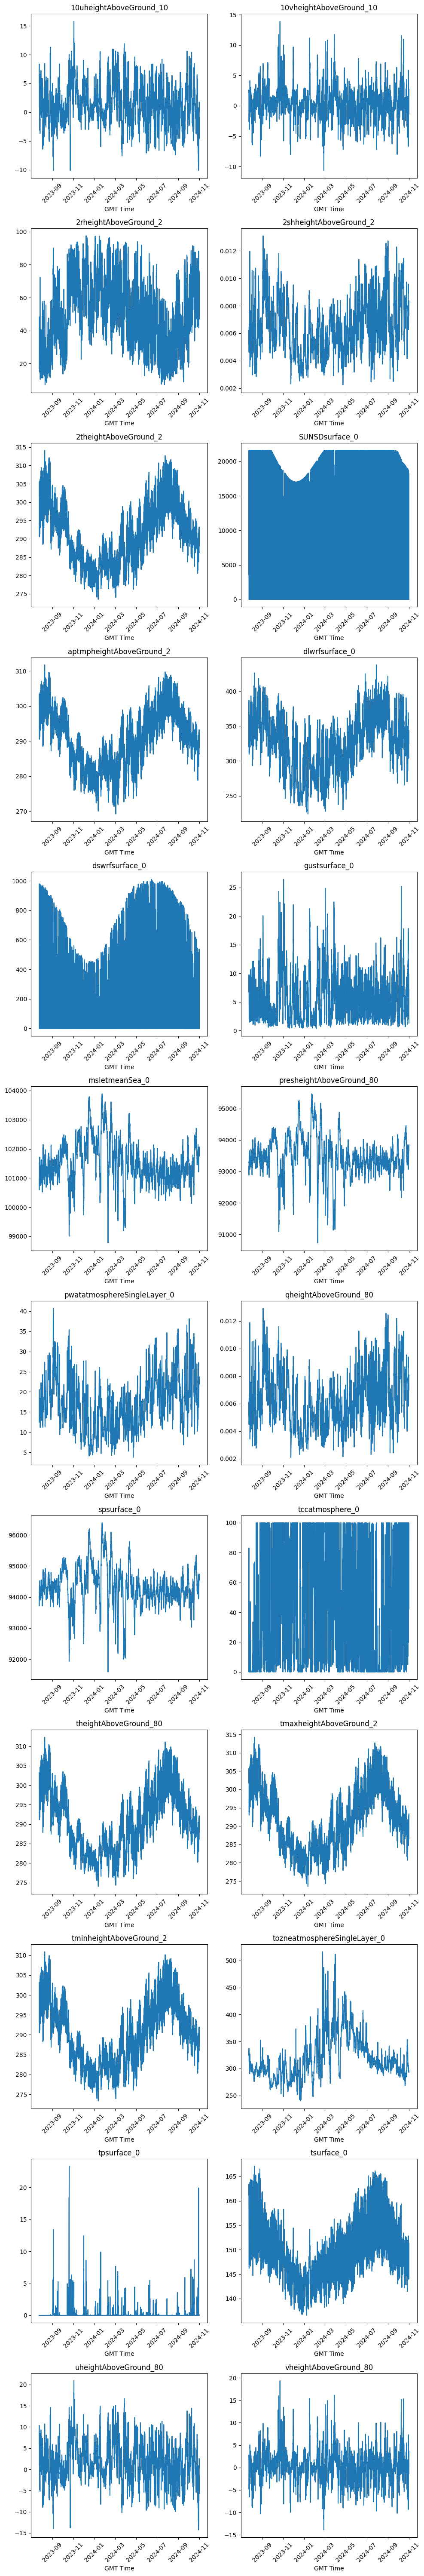

In [24]:

# Define the number of columns per row & calculate the number of rows required

plots_per_row = 2
n_cols = len(averaged_df.columns)
n_rows = math.ceil(n_cols / plots_per_row)

# Create subplots with 2 charts per row layout
fig, axes = plt.subplots(n_rows, plots_per_row, figsize=(5 * plots_per_row, 5 * n_rows))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each column
for i, column in enumerate(averaged_df.columns):
    axes[i].plot(averaged_df.index, averaged_df[column], label=column)
    axes[i].set_xlabel('GMT Time')
    axes[i].set_title(f'{column}')
    axes[i].tick_params(axis='x', rotation=45)

# Turn off unused subplots
for j in range(len(averaged_df.columns), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

## 2. Generation data + Weather Data

### 2.1. Merge generatin and weather data and check correlation

In [25]:
# change FECHA to datetime and rename columns in generation dataframe

convert_to_datetime(generation_df)

generation_df = generation_df.rename(columns={'TOTAL_KWH_ENERGIA': 'GEN_TOTAL_KWH_ENERGIA'})

# List of DataFrames to merge
dataframes_to_merge = [generation_df, averaged_df]

# Merge all DataFrames on 'FECHA' using reduce
plant_df = reduce(lambda left, right: pd.merge(left, right, on='FECHA', how='outer'), dataframes_to_merge)

#sort the dataframe based on date
plant_df.sort_values(by='FECHA', inplace=True)

# Save DataFrame to a CSV file
plant_df.to_csv('data/plant_data_with_AVERAGED_MET.csv', index=False)


Check for missing data in generation column

In [26]:
data = plant_df.copy()
data.set_index('FECHA', inplace=True)
print(data.shape)
print(data.isna().sum())

(11173, 25)
GEN_TOTAL_KWH_ENERGIA           2629
10uheightAboveGround_10            0
10vheightAboveGround_10            0
2rheightAboveGround_2              0
2shheightAboveGround_2             0
2theightAboveGround_2              0
SUNSDsurface_0                     0
aptmpheightAboveGround_2           0
dlwrfsurface_0                     0
dswrfsurface_0                     0
gustsurface_0                      0
msletmeanSea_0                     0
presheightAboveGround_80           0
pwatatmosphereSingleLayer_0        0
qheightAboveGround_80              0
spsurface_0                        0
tccatmosphere_0                    0
theightAboveGround_80              0
tmaxheightAboveGround_2            0
tminheightAboveGround_2            0
tozneatmosphereSingleLayer_0       0
tpsurface_0                        0
tsurface_0                         0
uheightAboveGround_80              0
vheightAboveGround_80              0
dtype: int64


Filling missing data

In [27]:
# Function to fill missing data based on rolling average of the same hour
def fill_missing_with_hourly_rolling_avg(df, column_name, window=5):
    # Extract the hour from the datetime index
    df['hour'] = df.index.hour
    
    # Create a new column to store the rolling averages
    filled_series = df[column_name].copy()
    
    for hour in range(24):  # Iterate through each hour
        # Filter data for the current hour
        hourly_data = df[df['hour'] == hour][column_name]
        
        # Calculate the rolling average over the last 'window' days (5 days * 24 hours = 240)
        rolling_avg = hourly_data.rolling(window=window * 24, min_periods=1).mean()
        
        # Fill missing values with the rolling average
        filled_series[hourly_data.index] = hourly_data.fillna(rolling_avg)
    
    return filled_series

data = data.copy()

# Apply the function to fill missing values
data['GEN_TOTAL_KWH_ENERGIA'] = fill_missing_with_hourly_rolling_avg(data, 'GEN_TOTAL_KWH_ENERGIA')

# Drop the 'hour' helper column if no longer needed
data.drop(columns=['hour'], inplace=True)

print(data.isna().sum())

GEN_TOTAL_KWH_ENERGIA           1
10uheightAboveGround_10         0
10vheightAboveGround_10         0
2rheightAboveGround_2           0
2shheightAboveGround_2          0
2theightAboveGround_2           0
SUNSDsurface_0                  0
aptmpheightAboveGround_2        0
dlwrfsurface_0                  0
dswrfsurface_0                  0
gustsurface_0                   0
msletmeanSea_0                  0
presheightAboveGround_80        0
pwatatmosphereSingleLayer_0     0
qheightAboveGround_80           0
spsurface_0                     0
tccatmosphere_0                 0
theightAboveGround_80           0
tmaxheightAboveGround_2         0
tminheightAboveGround_2         0
tozneatmosphereSingleLayer_0    0
tpsurface_0                     0
tsurface_0                      0
uheightAboveGround_80           0
vheightAboveGround_80           0
dtype: int64


In [28]:
data.dropna(inplace=True)

Checking the correlation between generation and weather data

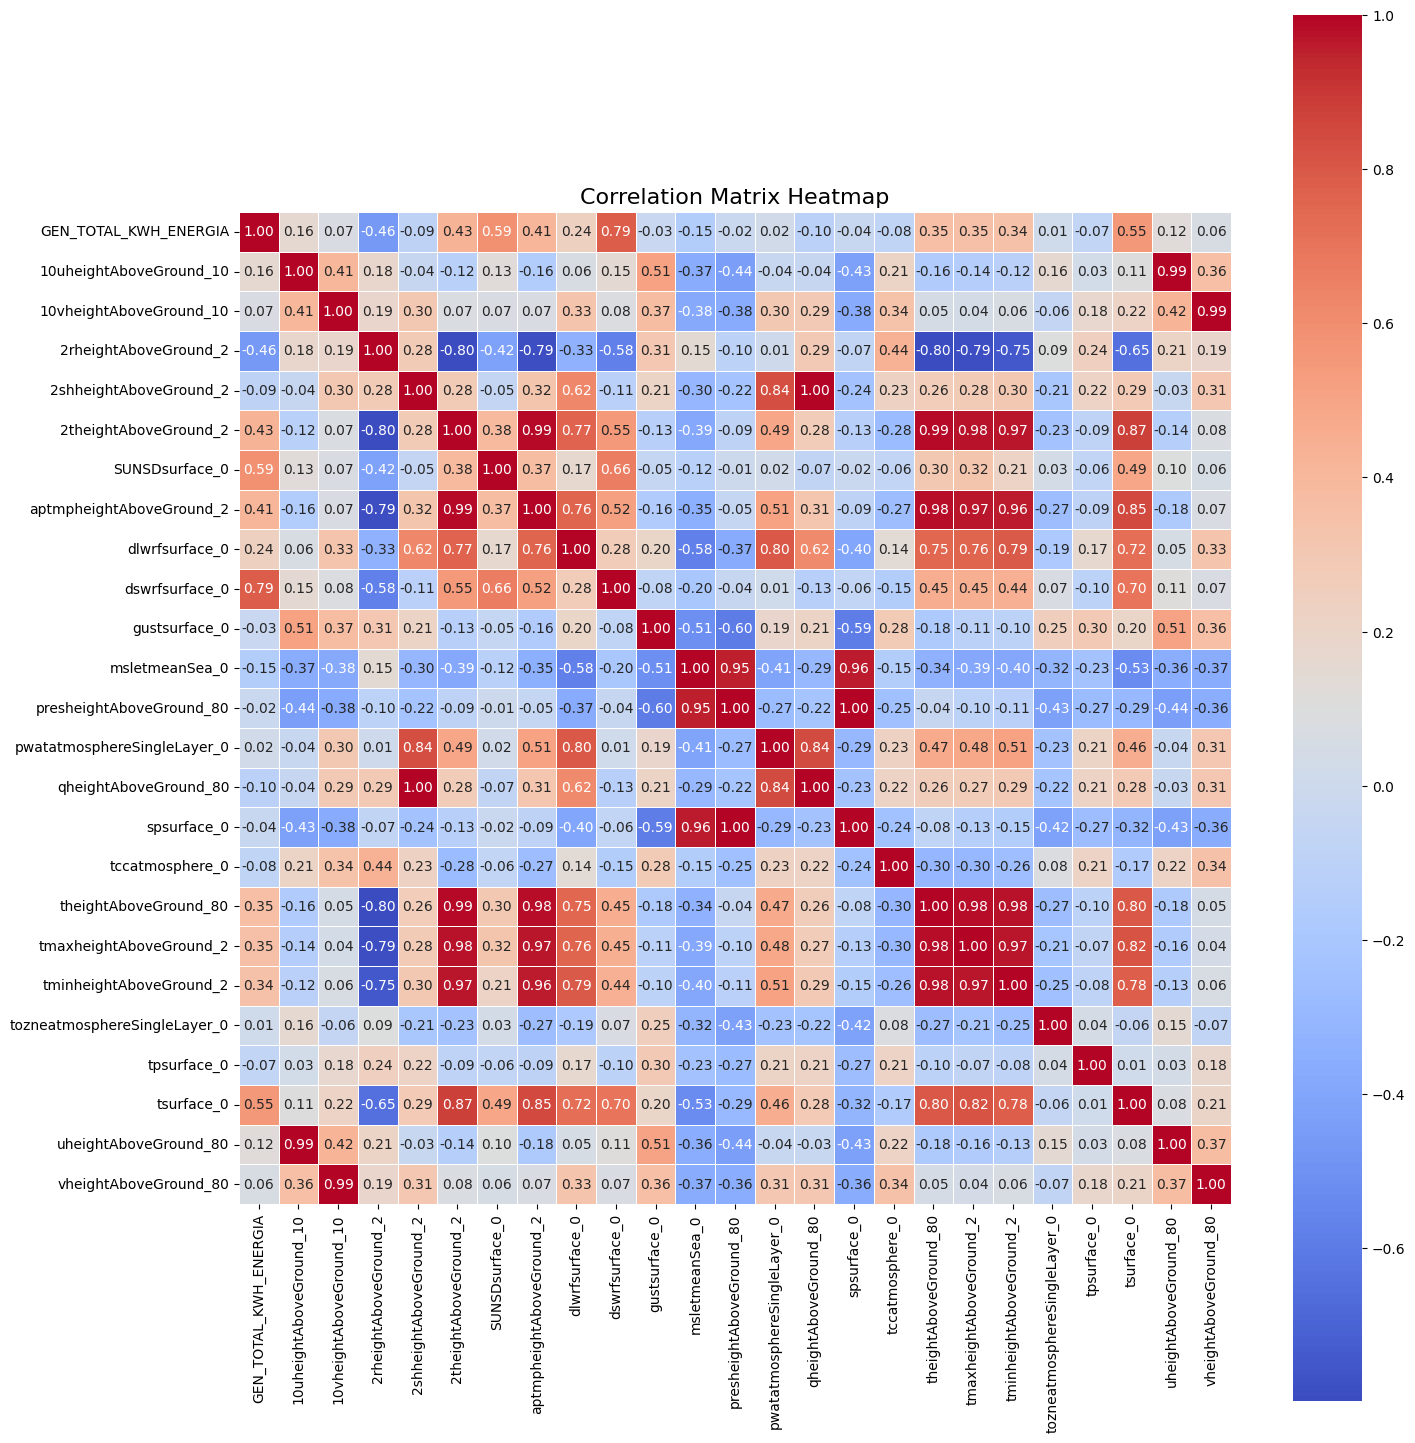

In [29]:
# Calculate the correlation matrix
correlation_matrix = data.corr()

# Create a heatmap
plt.figure(figsize=(16, 18))  
sns.heatmap(
    correlation_matrix,
    annot=True,  # Display the correlation values
    fmt='.2f',   # Format for the correlation values
    cmap='coolwarm',  # Color map for the heatmap
    cbar=True,   # Show color bar
    square=True,  # Make cells square-shaped
    linewidths=0.5  # Add gridlines
)

plt.title('Correlation Matrix Heatmap', fontsize=16)

plt.show()

**Correlation analysis with Photovoltaic Generation and Met Data**
- dswrfsurface_0	 0.78	surface shortwave radiation - Strongest predictor (irradiance) 
- SUNSDsurface_0	~0.56	Sunlight duration — moderate positive impact
- 2theightAboveGround_2	~0.42 Air temperature at 2m 
- tsurface_0	~0.55	Surface temp (similar to air temp)
- tccatmosphere_0	~-0.18	 Cloud cover (inverse relationship)


LATITUDE, LONGITUDE can be drop as we have only one station 
uheightAboveGround_80, vheightAboveGround_80, and wind-related features
Ozone, surface pressure, some redundant temps


# Objective 1: Calculation of Solar Generation Potential

## Model 1: XGBOOST (MAE = 13.1441)
Here the goal is to understand which variables influence solar energy generation using the model's feature importance

In [30]:
# Libraries for xgboost
import xgboost as xgb

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import train_test_split

In [31]:
df = data.copy()
df.reset_index(inplace=True)
df.head(2)

,FECHA,GEN_TOTAL_KWH_ENERGIA,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
0,2023-07-24 12:00:00,115.66,5.670802,2.579575,16.988889,0.004856,303.187798,21600.0,301.359812,324.429913,...,93949.704861,3.800000,300.411111,303.219008,293.290378,325.770036,0.0,162.559836,6.652786,2.790844
1,2023-07-24 13:00:00,129.98,6.260587,2.442148,17.077778,0.005225,304.332392,3600.0,302.303198,352.366667,...,93885.935417,38.833333,301.517803,304.326211,303.222222,326.296606,0.0,163.290270,7.447305,2.665181


In [32]:
df['hour'] = df['FECHA'].dt.hour
df['day'] = df['FECHA'].dt.day
df['month'] = df['FECHA'].dt.month
df['weekday'] = df['FECHA'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

df.head(2)


,FECHA,GEN_TOTAL_KWH_ENERGIA,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,...,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80,hour,day,month,weekday,is_weekend
0,2023-07-24 12:00:00,115.66,5.670802,2.579575,16.988889,0.004856,303.187798,21600.0,301.359812,324.429913,...,325.770036,0.0,162.559836,6.652786,2.790844,12,24,7,0,0
1,2023-07-24 13:00:00,129.98,6.260587,2.442148,17.077778,0.005225,304.332392,3600.0,302.303198,352.366667,...,326.296606,0.0,163.290270,7.447305,2.665181,13,24,7,0,0


### Baseline XGBoost

In [33]:
# Define  selected features (excluding unwanted columns)
excluded_cols = ['FECHA', 'GEN_TOTAL_KWH_ENERGIA']

selected_features = [col for col in df.columns if col not in excluded_cols]

# Prepare features (X) and target (y)
X = df[selected_features].fillna(df[selected_features].mean(numeric_only=True))
y = df.loc[X.index, 'GEN_TOTAL_KWH_ENERGIA']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

# Ensure both train and test have the same columns
common_cols = X_train.columns.intersection(X_test.columns)
X_train = X_train[common_cols]
X_test = X_test[common_cols]


# Train XGBoost
xg_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=20, random_state=42)
# Train the model
xg_reg.fit(X_train, y_train)

# Make predictions
preds_train = xg_reg.predict(X_train)
preds_test = xg_reg.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_train = mean_absolute_error(y_train, preds_train)
mae_test = mean_absolute_error(y_test, preds_test)

# Create DMatrix for Cross Validation: an optimized & compressed matrix used to store the datasets optimally in xgboost
data_dmatrix = xgb.DMatrix(data=X, label=y)

print(f"MAE (Train): {mae_train:.4f} kWh")
print(f"MAE (Test): {mae_test:.4f} kWh")
print(f"RMSE (Train): {rmse_train:.4f}")
print(f"RMSE (Test): {rmse_test:.4f}")


MAE (Train): 5.0417 kWh
MAE (Test): 7.0503 kWh
RMSE (Train): 9.3187
RMSE (Test): 13.6230


### Improve the XGBoost with Gridsearch

In [34]:
params = {'objective':'reg:squarederror', 'colsample_bytree':0.3, 'learning_rate':0.1, 'max_depth':5,
         'alpha':10}

cv_results = xgb.cv(dtrain=data_dmatrix, params=params, nfold = 3, num_boost_round=200, early_stopping_rounds=5,
                   metrics="rmse", as_pandas=True, seed=123)

cv_results

,train-rmse-mean,train-rmse-std,test-rmse-mean,test-rmse-std
0,38.230177,0.163493,38.365018,0.402766
1,35.395557,0.136940,35.546965,0.407485
2,34.862101,0.102251,35.079137,0.390759
3,33.402634,0.107469,33.707533,0.352420
4,32.189259,0.112230,32.563510,0.324684
...,...,...,...,...
195,8.480279,0.050572,13.757074,0.177735
196,8.456769,0.048040,13.747029,0.179415
197,8.442857,0.049224,13.743825,0.181668
198,8.429511,0.050926,13.738869,0.180769


In [35]:
gbm_param_grid = {'learning_rate': [0.01, 0.1, 0.2], 'subsample':[0.3,0.4,0.5]} 
gbm = xgb.XGBRegressor()

grid_mse = GridSearchCV(estimator=gbm, param_grid=gbm_param_grid, scoring='neg_mean_squared_error', cv=5, verbose=2)
grid_mse.fit(X, y)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END ..................learning_rate=0.01, subsample=0.3; total time=   0.3s
[CV] END ..................learning_rate=0.01, subsample=0.3; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.3; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.3; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.3; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.4; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.4; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.4; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.4; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.4; total time=   0.1s
[CV] END ..................learning_rate=0.01, subsample=0.5; total time=   0.2s
[CV] END ..................learning_rate=0.01, su

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'subsample': [0.3, 0.4, 0.5]},
             scoring='neg_mean_squared_error', verbose=2)

In [36]:
#Print best performing parameters and their RMSE scores
print('Best parameters found: ', grid_mse.best_params_)
print('Lowerst RMSE found: ', np.sqrt(np.sqrt(np.abs(grid_mse.best_score_))))

Best parameters found:  {'learning_rate': 0.1, 'subsample': 0.5}
Lowerst RMSE found:  4.541442720539744


Fit model with parameters from gridsearch

In [37]:
# Train XGBoost With best params from gridsearch
xg_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=20,             
    learning_rate=0.1,           
    subsample=0.5,                
    random_state=42
)

xg_reg.fit(X_train, y_train)

# Make predictions
preds_train = xg_reg.predict(X_train)
preds_test = xg_reg.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, preds_train))
rmse_test = np.sqrt(mean_squared_error(y_test, preds_test))
mae_train = mean_absolute_error(y_train, preds_train)
mae_test = mean_absolute_error(y_test, preds_test)

# Create DMatrix for Cross Validation: an optimized & compressed matrix used to store the datasets optimally in xgboost
data_dmatrix = xgb.DMatrix(data=X, label=y)

print(f"MAE (Train): {mae_train:.4f} kWh")
print(f"MAE (Test): {mae_test:.4f} kWh")
print(f"RMSE (Train): {rmse_train:.4f}")
print(f"RMSE (Test): {rmse_test:.4f}")

MAE (Train): 9.1853 kWh
MAE (Test): 9.9396 kWh
RMSE (Train): 14.1269
RMSE (Test): 15.7561


Getting the variables importance in predicting energy generation

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

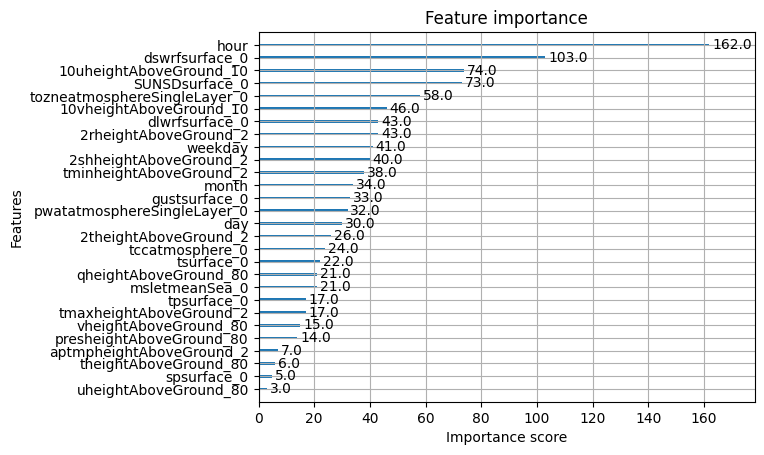

In [38]:
xgb.plot_importance(xg_reg, importance_type="weight")

### September 2024 prediction

In [39]:
# Filter the data for September 2024
september_2024_data = plant_df[(plant_df['FECHA'] >= '2024-09-01') & (plant_df['FECHA'] < '2024-10-01')].copy()

# Extract features for prediction
september_2024_data['hour'] = september_2024_data['FECHA'].dt.hour
september_2024_data['day'] = september_2024_data['FECHA'].dt.day
september_2024_data['month'] = september_2024_data['FECHA'].dt.month
september_2024_data['weekday'] = september_2024_data['FECHA'].dt.weekday
september_2024_data['is_weekend'] = september_2024_data['weekday'].isin([5, 6]).astype(int)

# Select the same features used for training
X_september = september_2024_data[selected_features].fillna(september_2024_data[selected_features].mean(numeric_only=True))

# Make predictions
september_2024_data['Predicted_GEN_TOTAL_KWH_ENERGIA'] = xg_reg.predict(X_september)

# Display the predictions
print(september_2024_data[['FECHA', 'Predicted_GEN_TOTAL_KWH_ENERGIA']].head())


                   FECHA  Predicted_GEN_TOTAL_KWH_ENERGIA
9709 2024-09-01 00:00:00                         3.341496
9710 2024-09-01 01:00:00                         3.341496
9711 2024-09-01 02:00:00                         3.341496
9712 2024-09-01 03:00:00                         3.341496
9713 2024-09-01 04:00:00                         3.341496


In [40]:
september_2024_data[['FECHA', 'Predicted_GEN_TOTAL_KWH_ENERGIA']]

,FECHA,Predicted_GEN_TOTAL_KWH_ENERGIA
9709,2024-09-01 00:00:00,3.341496
9710,2024-09-01 01:00:00,3.341496
9711,2024-09-01 02:00:00,3.341496
9712,2024-09-01 03:00:00,3.341496
9713,2024-09-01 04:00:00,3.341496
...,...,...
10424,2024-09-30 19:00:00,35.550758
10425,2024-09-30 20:00:00,19.838575
10426,2024-09-30 21:00:00,6.335830
10427,2024-09-30 22:00:00,4.131028


In [41]:
# Save predictions
september_2024_data.set_index('FECHA')[['Predicted_GEN_TOTAL_KWH_ENERGIA']].to_csv('xgboost_september_2024_predictions.csv')

## Model 2: RNN = MAE = 12.0967

Libraries required for RNN

In [42]:
from scipy.stats import shapiro  
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from sklearn.preprocessing import MinMaxScaler

In [43]:
data = plant_df.copy()
data.set_index('FECHA', inplace=True)
print(data.shape)
print(data.isna().sum())

(11173, 25)
GEN_TOTAL_KWH_ENERGIA           2629
10uheightAboveGround_10            0
10vheightAboveGround_10            0
2rheightAboveGround_2              0
2shheightAboveGround_2             0
2theightAboveGround_2              0
SUNSDsurface_0                     0
aptmpheightAboveGround_2           0
dlwrfsurface_0                     0
dswrfsurface_0                     0
gustsurface_0                      0
msletmeanSea_0                     0
presheightAboveGround_80           0
pwatatmosphereSingleLayer_0        0
qheightAboveGround_80              0
spsurface_0                        0
tccatmosphere_0                    0
theightAboveGround_80              0
tmaxheightAboveGround_2            0
tminheightAboveGround_2            0
tozneatmosphereSingleLayer_0       0
tpsurface_0                        0
tsurface_0                         0
uheightAboveGround_80              0
vheightAboveGround_80              0
dtype: int64


### Fit RNN Model

Fill in missing values

In [44]:
# Function to fill missing data based on rolling average of the same hour
def fill_missing_with_hourly_rolling_avg(df, column_name, window=5):
    # Extract the hour from the datetime index
    df['hour'] = df.index.hour
    
    # Create a new column to store the rolling averages
    filled_series = df[column_name].copy()
    
    for hour in range(24):  # Iterate through each hour
        # Filter data for the current hour
        hourly_data = df[df['hour'] == hour][column_name]
        
        # Calculate the rolling average over the last 'window' days (5 days * 24 hours = 240)
        rolling_avg = hourly_data.rolling(window=window * 24, min_periods=1).mean()
        
        # Fill missing values with the rolling average
        filled_series[hourly_data.index] = hourly_data.fillna(rolling_avg)
    
    return filled_series

data = data.copy()

# Apply the function to fill missing values
data['GEN_TOTAL_KWH_ENERGIA'] = fill_missing_with_hourly_rolling_avg(data, 'GEN_TOTAL_KWH_ENERGIA')

# Drop the 'hour' helper column if no longer needed
data.drop(columns=['hour'], inplace=True)

print(data.isna().sum())

GEN_TOTAL_KWH_ENERGIA           1
10uheightAboveGround_10         0
10vheightAboveGround_10         0
2rheightAboveGround_2           0
2shheightAboveGround_2          0
2theightAboveGround_2           0
SUNSDsurface_0                  0
aptmpheightAboveGround_2        0
dlwrfsurface_0                  0
dswrfsurface_0                  0
gustsurface_0                   0
msletmeanSea_0                  0
presheightAboveGround_80        0
pwatatmosphereSingleLayer_0     0
qheightAboveGround_80           0
spsurface_0                     0
tccatmosphere_0                 0
theightAboveGround_80           0
tmaxheightAboveGround_2         0
tminheightAboveGround_2         0
tozneatmosphereSingleLayer_0    0
tpsurface_0                     0
tsurface_0                      0
uheightAboveGround_80           0
vheightAboveGround_80           0
dtype: int64


In [45]:
data.dropna(inplace=True)
data.tail()

,GEN_TOTAL_KWH_ENERGIA,10uheightAboveGround_10,10vheightAboveGround_10,2rheightAboveGround_2,2shheightAboveGround_2,2theightAboveGround_2,SUNSDsurface_0,aptmpheightAboveGround_2,dlwrfsurface_0,dswrfsurface_0,...,spsurface_0,tccatmosphere_0,theightAboveGround_80,tmaxheightAboveGround_2,tminheightAboveGround_2,tozneatmosphereSingleLayer_0,tpsurface_0,tsurface_0,uheightAboveGround_80,vheightAboveGround_80
FECHA,,,,,,,,,,,,,,,,,,,,,
2024-10-31 19:00:00,51.288868,1.712167,-0.120578,73.222222,0.008330,288.451378,0.0,288.458230,332.734110,0.0,...,94665.164583,42.044444,288.438051,289.342572,288.244711,295.169328,0.013889,145.564771,2.547099,0.112466
2024-10-31 20:00:00,27.283962,1.172493,0.060525,75.133333,0.008365,288.053681,0.0,288.046803,326.544554,0.0,...,94687.728819,54.911111,288.217674,289.467016,287.635614,295.584785,0.013889,144.642414,1.844787,0.230565
2024-10-31 21:00:00,6.978491,0.838918,0.100157,74.722222,0.008353,288.091836,0.0,288.100517,328.326836,0.0,...,94711.029167,71.344444,288.150030,289.579238,287.398305,295.179774,0.013889,144.483788,1.417429,0.248963
2024-10-31 22:00:00,0.702830,0.230694,0.130402,74.233333,0.008353,288.164748,0.0,288.187877,332.423588,0.0,...,94727.309028,88.144444,288.075634,289.626970,287.278305,294.312722,0.020833,144.390846,0.637383,0.258828
2024-10-31 23:00:00,-0.012453,0.101007,0.667309,73.988889,0.008331,288.179941,0.0,288.184033,337.176019,0.0,...,94733.415278,98.455556,287.908186,289.635497,287.192750,292.976552,0.027778,144.534890,0.324520,0.899162


In [46]:
# Filter data for the required time periods
train_data = data[(data.index >= '2024-01-01') & (data.index <= '2024-07-31')]
test_data = data[(data.index >= '2024-08-01') & (data.index <= '2024-08-30')]
predict_data = data[(data.index >= '2024-08-31') & (data.index <= '2024-10-01')]

# Scale the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data[['GEN_TOTAL_KWH_ENERGIA']])
scaled_test = scaler.transform(test_data[['GEN_TOTAL_KWH_ENERGIA']])
scaled_predict = scaler.transform(predict_data[['GEN_TOTAL_KWH_ENERGIA']])

# Create sequences for LSTM
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i + sequence_length, 0])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

sequence_length = 24  # Use the past 24 hours to predict the next value
X_train, y_train = create_sequences(scaled_train, sequence_length)
X_test, y_test = create_sequences(scaled_test, sequence_length)

# Reshape data for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build the LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Make predictions for September 2024
X_predict, _ = create_sequences(scaled_predict, sequence_length)
X_predict = X_predict.reshape((X_predict.shape[0], X_predict.shape[1], 1))
predictions = model.predict(X_predict)

# Inverse transform the predictions to get the original scale
predicted_values = scaler.inverse_transform(predictions)

# Add predictions to the predict_data DataFrame
predict_data.loc[predict_data.index[sequence_length:], 'Predicted_GEN_TOTAL_KWH_ENERGIA'] = predicted_values.flatten()

# Save predictions
predict_data[['Predicted_GEN_TOTAL_KWH_ENERGIA']].to_csv('lstm_september_2024_predictions.csv')

# Display the predictions
print(predict_data[['Predicted_GEN_TOTAL_KWH_ENERGIA']])



Epoch 1/20


c:\Users\Wambui\Documents\MBD SCHOOL WORK\REPSOL DATATHON\finance_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


159/159 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0513 - val_loss: 0.0183
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0152 - val_loss: 0.0183
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0126 - val_loss: 0.0153
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0115 - val_loss: 0.0133
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0094 - val_loss: 0.0117
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0078 - val_loss: 0.0113
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0076 - val_loss: 0.0100
Epoch 8/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0068 - val_loss: 0.0093
Epoch 9/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0072 - val_loss: 0.0102
Epoch 10/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0072 - val_loss: 0.0095
Epoch 11/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0060 - val_loss: 0.0093
Epoch 12/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/ste

C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\1366207949.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  predict_data.loc[predict_data.index[sequence_length:], 'Predicted_GEN_TOTAL_KWH_ENERGIA'] = predicted_values.flatten()


### September Predictions

In [47]:
# Filter for September dates
september_predictions = predict_data[predict_data.index.month == 9][['Predicted_GEN_TOTAL_KWH_ENERGIA']]

# Display the result
print(september_predictions)

                     Predicted_GEN_TOTAL_KWH_ENERGIA
FECHA                                               
2024-09-01 00:00:00                        -1.074365
2024-09-01 01:00:00                        -0.592321
2024-09-01 02:00:00                        -0.101211
2024-09-01 03:00:00                         0.299036
2024-09-01 04:00:00                         0.547100
...                                              ...
2024-09-30 19:00:00                        47.928814
2024-09-30 20:00:00                        21.106550
2024-09-30 21:00:00                         6.421654
2024-09-30 22:00:00                         0.420492
2024-09-30 23:00:00                        -1.124919

[720 rows x 1 columns]


In [48]:
september_predictions.to_csv('lstm_september_gen_predictions.csv')

## Model 3: SARIMAX  (MAE = 6.8045) 

### Prepare data for SARIMAX

In [49]:
data = plant_df[(plant_df['FECHA'] < pd.Timestamp('2024-09-01')) & (plant_df['FECHA'] >= pd.Timestamp('2024-07-01'))]
data.set_index('FECHA', inplace=True)
print(data.shape)
print(data.isna().sum())


(1488, 25)
GEN_TOTAL_KWH_ENERGIA           163
10uheightAboveGround_10           0
10vheightAboveGround_10           0
2rheightAboveGround_2             0
2shheightAboveGround_2            0
2theightAboveGround_2             0
SUNSDsurface_0                    0
aptmpheightAboveGround_2          0
dlwrfsurface_0                    0
dswrfsurface_0                    0
gustsurface_0                     0
msletmeanSea_0                    0
presheightAboveGround_80          0
pwatatmosphereSingleLayer_0       0
qheightAboveGround_80             0
spsurface_0                       0
tccatmosphere_0                   0
theightAboveGround_80             0
tmaxheightAboveGround_2           0
tminheightAboveGround_2           0
tozneatmosphereSingleLayer_0      0
tpsurface_0                       0
tsurface_0                        0
uheightAboveGround_80             0
vheightAboveGround_80             0
dtype: int64


In [50]:
# Function to fill missing data based on rolling average of the same hour
def fill_missing_with_hourly_rolling_avg(df, column_name, window=5):
    # Extract the hour from the datetime index
    df['hour'] = df.index.hour
    
    # Create a new column to store the rolling averages
    filled_series = df[column_name].copy()
    
    for hour in range(24):  # Iterate through each hour
        # Filter data for the current hour
        hourly_data = df[df['hour'] == hour][column_name]
        
        # Calculate the rolling average over the last 'window' days (5 days * 24 hours = 240)
        rolling_avg = hourly_data.rolling(window=window * 24, min_periods=1).mean()
        
        # Fill missing values with the rolling average
        filled_series[hourly_data.index] = hourly_data.fillna(rolling_avg)
    
    return filled_series

data = data.copy()

# Apply the function to fill missing values
data['GEN_TOTAL_KWH_ENERGIA'] = fill_missing_with_hourly_rolling_avg(data, 'GEN_TOTAL_KWH_ENERGIA')

# Drop the 'hour' helper column if no longer needed
data.drop(columns=['hour'], inplace=True)

print(data.isna().sum())

GEN_TOTAL_KWH_ENERGIA           0
10uheightAboveGround_10         0
10vheightAboveGround_10         0
2rheightAboveGround_2           0
2shheightAboveGround_2          0
2theightAboveGround_2           0
SUNSDsurface_0                  0
aptmpheightAboveGround_2        0
dlwrfsurface_0                  0
dswrfsurface_0                  0
gustsurface_0                   0
msletmeanSea_0                  0
presheightAboveGround_80        0
pwatatmosphereSingleLayer_0     0
qheightAboveGround_80           0
spsurface_0                     0
tccatmosphere_0                 0
theightAboveGround_80           0
tmaxheightAboveGround_2         0
tminheightAboveGround_2         0
tozneatmosphereSingleLayer_0    0
tpsurface_0                     0
tsurface_0                      0
uheightAboveGround_80           0
vheightAboveGround_80           0
dtype: int64


Check trend, seasonal and Noise components of solar generation time series

In [51]:
# Perform seasonal decomposition
result = seasonal_decompose(data['GEN_TOTAL_KWH_ENERGIA'], model='additive', period=24)


# Original time series
fig_original = go.Figure()
fig_original.add_trace(go.Scatter(x=data.index, y=data['GEN_TOTAL_KWH_ENERGIA'], mode='lines', name='Original'))
fig_original.update_layout(title='Original Time Series', xaxis_title='Time', yaxis_title='GEN_TOTAL_KWH_ENERGIA')
fig_original.show()

# Trend component
fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(x=data.index, y=result.trend, mode='lines', name='Trend', line=dict(color='orange')))
fig_trend.update_layout(title='Trend Component', xaxis_title='Time', yaxis_title='Trend')
fig_trend.show()

# Seasonal component
fig_seasonal = go.Figure()
fig_seasonal.add_trace(go.Scatter(x=data.index, y=result.seasonal, mode='lines', name='Seasonal', line=dict(color='green')))
fig_seasonal.update_layout(title='Seasonal Component', xaxis_title='Time', yaxis_title='Seasonal')
fig_seasonal.show()

# Residual component
fig_residual = go.Figure()
fig_residual.add_trace(go.Scatter(x=data.index, y=result.resid, mode='lines', name='Residual', line=dict(color='red')))
fig_residual.update_layout(title='Residual Component', xaxis_title='Time', yaxis_title='Residual')
fig_residual.show()

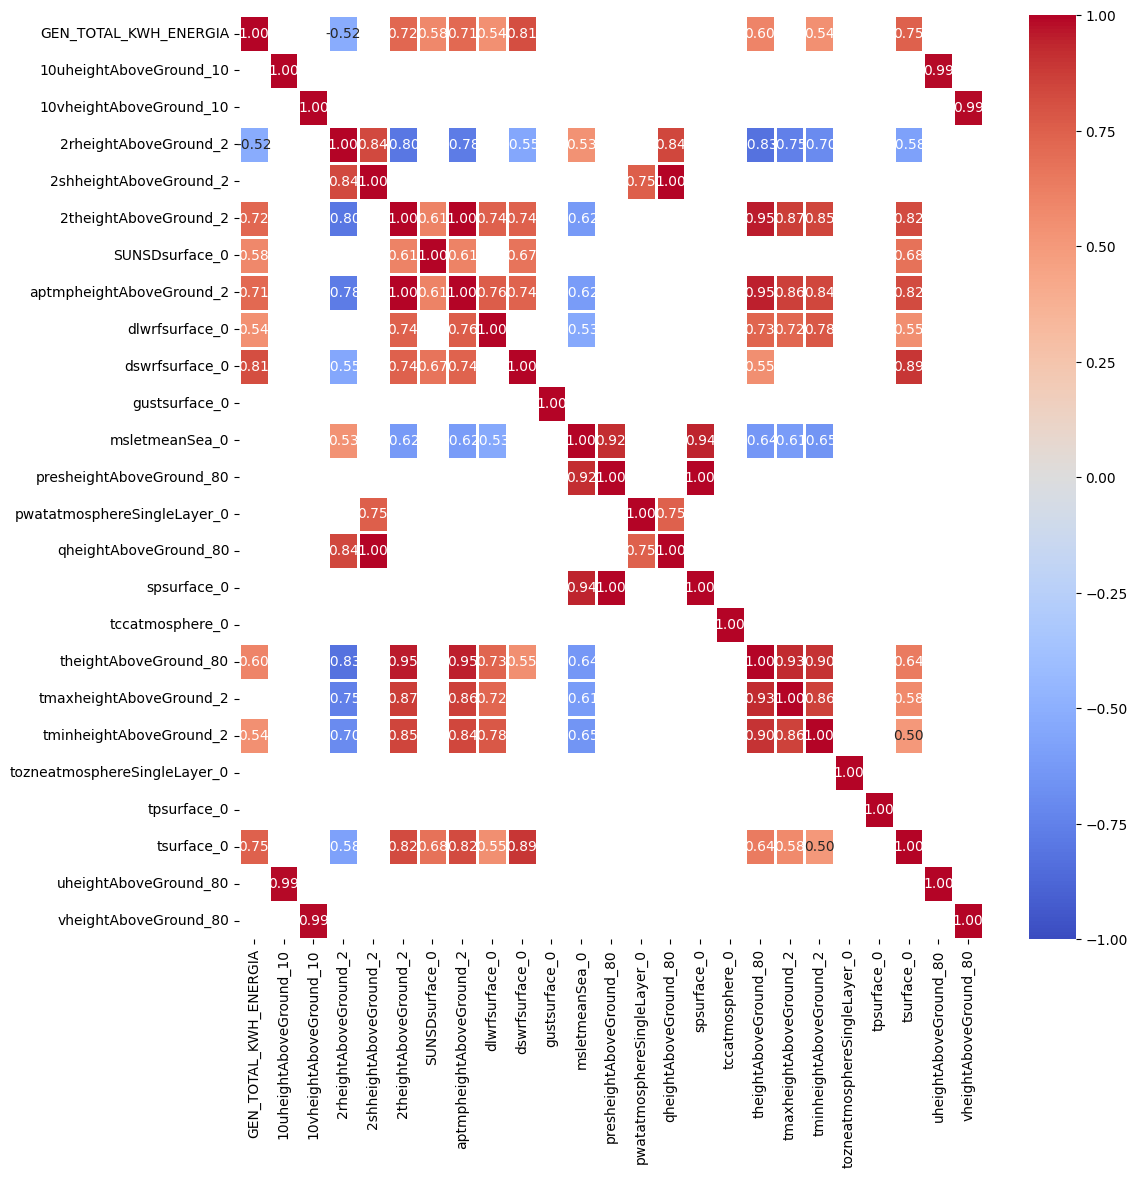

In [52]:
data.dropna(inplace=True)

# Compute the correlation matrix
corr_matrix = data.corr()

# Apply a mask to hide values with abs(correlation) <= 0.5
mask = corr_matrix.abs() <= 0.5
filtered_corr_matrix = corr_matrix.mask(mask)

# Plot the heatmap
fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(filtered_corr_matrix, annot=True, fmt=".2f", linewidths=1, ax=ax, cmap="coolwarm", vmin=-1, vmax=1)

plt.show()

In [53]:
# Compute the correlation matrix
corr_matrix = df.corr()

# Get the correlations for GEN_TOTAL_KWH_ENERGIA and filter for abs(value) > 0.5
filtered_corr = corr_matrix['GEN_TOTAL_KWH_ENERGIA'].loc[(corr_matrix['GEN_TOTAL_KWH_ENERGIA'].abs() > 0.75) & (corr_matrix['GEN_TOTAL_KWH_ENERGIA'].abs() != 1)]

# Output the filtered correlations
print(filtered_corr)

dswrfsurface_0    0.788131
Name: GEN_TOTAL_KWH_ENERGIA, dtype: float64


### Fit SARIMAX model with dswfsurface as independent variable

In [54]:
exog_variables = filtered_corr.to_frame().index.to_list()
exog_data = data[exog_variables]

# Fit the final model
final_model = SARIMAX(data['GEN_TOTAL_KWH_ENERGIA'], 
                      exog=exog_data, 
                      order=(1, 1, 0), 
                      seasonal_order=(1, 1, 0, 24), 
                      enforce_stationarity=False, 
                      enforce_invertibility=False)

final_results = final_model.fit()

# Print summary of the final model
print(final_results.summary())

c:\Users\Wambui\Documents\MBD SCHOOL WORK\REPSOL DATATHON\finance_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency h will be used.

c:\Users\Wambui\Documents\MBD SCHOOL WORK\REPSOL DATATHON\finance_env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency h will be used.



                                     SARIMAX Results                                      
Dep. Variable:              GEN_TOTAL_KWH_ENERGIA   No. Observations:                 1488
Model:             SARIMAX(1, 1, 0)x(1, 1, 0, 24)   Log Likelihood               -6190.722
Date:                            Fri, 28 Mar 2025   AIC                          12389.444
Time:                                    09:36:31   BIC                          12410.528
Sample:                                07-01-2024   HQIC                         12397.315
                                     - 08-31-2024                                         
Covariance Type:                              opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
dswrfsurface_0     0.0409      0.017      2.353      0.019       0.007       0.075
ar.L1              0.06

In [55]:
# Generate predictions for the same time range as the actual data
predicted_values = final_results.predict(start=data.index[0], end=data.index[-1], exog=exog_data)

predicted_values

# Clip the predicted values to ensure they are within the range [0, 175]
predicted_values_clipped = predicted_values.clip(lower=0, upper=175)

# Display the clipped predictions
predicted_values_clipped

2024-07-01 00:00:00     1.097929
2024-07-01 01:00:00     0.000000
2024-07-01 02:00:00     0.036085
2024-07-01 03:00:00     0.001209
2024-07-01 04:00:00     0.000041
                         ...    
2024-08-31 19:00:00    38.150901
2024-08-31 20:00:00    31.776049
2024-08-31 21:00:00    14.113904
2024-08-31 22:00:00     4.528504
2024-08-31 23:00:00     0.490466
Freq: h, Name: predicted_mean, Length: 1488, dtype: float64

In [56]:
# Ensure the actual and predicted values are aligned
actual_values = data['GEN_TOTAL_KWH_ENERGIA']
predicted_values_aligned = predicted_values_clipped.loc[actual_values.index]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual_values, predicted_values_aligned))

# Calculate MAE
mae = mean_absolute_error(actual_values, predicted_values_aligned)

# Calculate R-squared
r_squared = r2_score(actual_values, predicted_values_aligned)

# Print the results
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R-squared: {r_squared}")

RMSE: 17.2421817523727
MAE: 8.097986051288
R-squared: 0.8515355130997669


In [57]:
# Create the Plotly figure
fig = go.Figure()

# Add the actual values trace
fig.add_trace(go.Scatter(
    x=data.index, 
    y=data['GEN_TOTAL_KWH_ENERGIA'], 
    mode='lines', 
    name='Actual', 
    line=dict(color='blue')
))

# Add the predicted values trace
fig.add_trace(go.Scatter(
    x=data.index, 
    y=predicted_values_clipped, 
    mode='lines', 
    name='Predicted', 
    line=dict(color='red', dash='dash')  # Dashed line for predicted values
))

# Customize the layout
fig.update_layout(
    title='Actual vs Predicted Energy Generation',
    xaxis_title='Date',
    yaxis_title='Energy (kWh)',
    legend_title='Legend',
    template='plotly',  # Default Plotly theme
    autosize=True,  # Ensure the figure resizes well
    font=dict(size=12)  # Adjust font size
)

# Show the plot
fig.show()

Model residual analysis

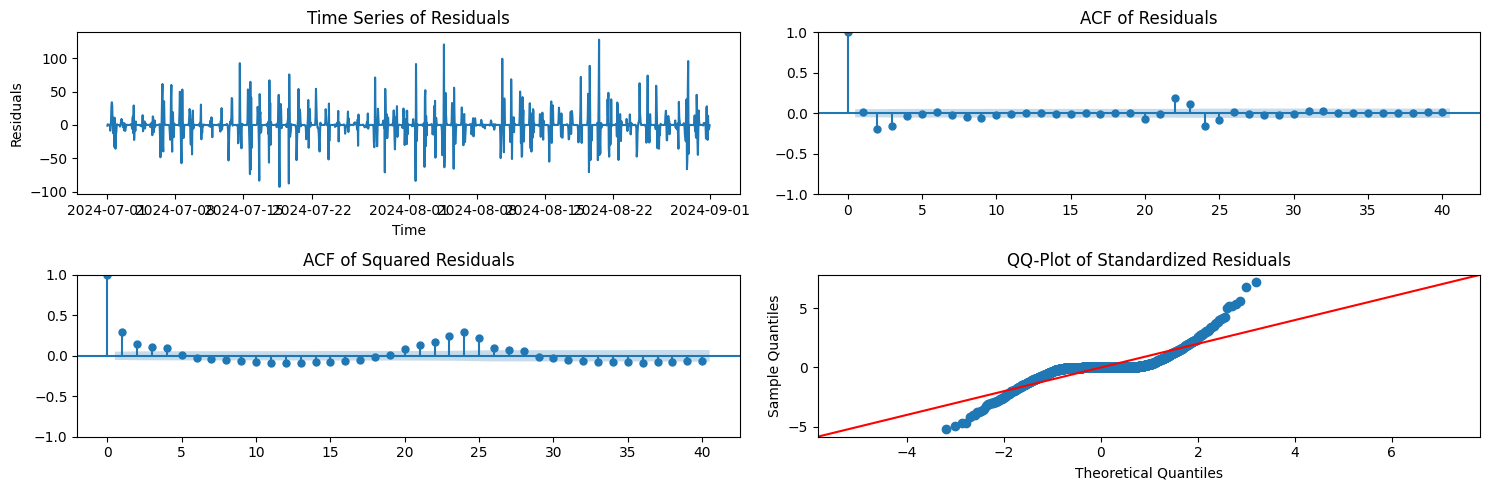

In [61]:
# 'final_results' is SARIMAX model from which we extract residuals.
resid = final_results.resid
resid_sq = resid ** 2

# Standardize the residuals for the QQ-plot.
resid_std = (resid - resid.mean()) / resid.std()

# Create a 2x2 grid of diagnostic plots
fig, axs = plt.subplots(2, 2, figsize=(15, 5))

# Top-Left: Time Series of Residuals
axs[0, 0].plot(resid, linestyle='-')
axs[0, 0].set_title("Time Series of Residuals")
axs[0, 0].set_xlabel("Time")
axs[0, 0].set_ylabel("Residuals")

# Top-Right: ACF of Residuals
sm.graphics.tsa.plot_acf(resid, lags=40, ax=axs[0, 1])
axs[0, 1].set_title("ACF of Residuals")

# Bottom-Left: ACF of Squared Residuals
sm.graphics.tsa.plot_acf(resid_sq, lags=40, ax=axs[1, 0])
axs[1, 0].set_title("ACF of Squared Residuals")

# Bottom-Right: QQ-Plot of Standardized Residuals
sm.qqplot(resid_std, line='45', ax=axs[1, 1])
axs[1, 1].set_title("QQ-Plot of Standardized Residuals")

plt.tight_layout()
plt.show()


### September Predictions

In [62]:
# Filter exogenous variables to include only the specified columns
exog_data = data[exog_variables]

# Prepare the exogenous data for September 2024
september_2024_exog = averaged_df.loc[
    (averaged_df.index >= pd.Timestamp('2024-09-01')) & 
    (averaged_df.index < pd.Timestamp('2024-10-01')),
    exog_variables
]

In [63]:
# Generate predictions for September 2024
september_2024_predictions = final_results.predict(
    start=pd.Timestamp('2024-09-01 00:00:00'),
    end=pd.Timestamp('2024-09-30 23:00:00'),
    exog=september_2024_exog
)

# Clip the predictions to ensure they are within a reasonable range
september_2024_predictions_clipped = september_2024_predictions.clip(lower=0, upper=175)

# Display the predictions
print(september_2024_predictions_clipped)

2024-09-01 00:00:00     0.000000
2024-09-01 01:00:00     0.000000
2024-09-01 02:00:00     0.000000
2024-09-01 03:00:00     0.000000
2024-09-01 04:00:00     0.000000
                         ...    
2024-09-30 19:00:00    38.481720
2024-09-30 20:00:00    19.895139
2024-09-30 21:00:00     3.505941
2024-09-30 22:00:00     0.000000
2024-09-30 23:00:00     0.000000
Freq: h, Name: predicted_mean, Length: 720, dtype: float64


In [64]:
#Create a pandas Series
energy_predictions = september_2024_predictions_clipped

In [65]:
# Save energy_predictions to a CSV file with the specified column name
energy_predictions.to_frame(name='Predicted_GEN_TOTAL_KWH_ENERGIA').to_csv('sarimax_gen_predictions_2.csv', index=True)

print("DataFrame saved to 'sarimax_gen_predictions_2.csv' with the index included")


DataFrame saved to 'sarimax_gen_predictions_2.csv' with the index included


# Objective 2: Optimization of Battery Usage in the Installation

### Merge plant consumption and generation data

In [66]:
# Rename the column 'TOTAL_KWH_ENERGIA' to 'PLANTTOTAL_KWH_ENERGIA' and reset the index
sept_total_consumption_df = sept_total_consumption_df.rename(columns={'TOTAL_KWH_ENERGIA': 'PLANT_TOTAL_KWH_ENERGIA'})
sept_total_consumption_df.head(2)

,FECHA,PLANT_TOTAL_KWH_ENERGIA
0,2024-09-01 00:00:00,110.855888
1,2024-09-01 01:00:00,107.341202


In [67]:
sept_solar_consumption_df = sept_solar_consumption_df.rename(columns={'TOTAL_KWH_ENERGIA': 'SOLAR_CONS_KWH_ENERGIA'})
sept_solar_consumption_df.head(2)

,FECHA,SOLAR_CONS_KWH_ENERGIA
0,2024-09-01 00:00:00+02:00,0.0
1,2024-09-01 01:00:00+02:00,0.0


In [68]:
sept_solar_consumption_df["FECHA"] = sept_solar_consumption_df["FECHA"].dt.tz_localize(None)
sept_solar_consumption_df.head(2)

,FECHA,SOLAR_CONS_KWH_ENERGIA
0,2024-09-01 00:00:00,0.0
1,2024-09-01 01:00:00,0.0


In [69]:
energy_predictions = energy_predictions.to_frame(name='Predicted_GEN_TOTAL_KWH_ENERGIA')
energy_predictions.head(2)

,Predicted_GEN_TOTAL_KWH_ENERGIA
2024-09-01 00:00:00,0.0
2024-09-01 01:00:00,0.0


In [70]:
energy_predictions.reset_index(inplace=True)
energy_predictions.rename(columns={'index': 'FECHA'}, inplace=True)

In [71]:
energy_predictions.head()

,FECHA,Predicted_GEN_TOTAL_KWH_ENERGIA
0,2024-09-01 00:00:00,0.0
1,2024-09-01 01:00:00,0.0
2,2024-09-01 02:00:00,0.0
3,2024-09-01 03:00:00,0.0
4,2024-09-01 04:00:00,0.0


In [72]:
# Merge the dataframes on FECHA
merged_df = pd.merge(sept_total_consumption_df, sept_solar_consumption_df, on='FECHA', how='inner')
final_df = pd.merge(merged_df, energy_predictions, on='FECHA', how='inner')

# Display the merged dataframe
final_df.head()

,FECHA,PLANT_TOTAL_KWH_ENERGIA,SOLAR_CONS_KWH_ENERGIA,Predicted_GEN_TOTAL_KWH_ENERGIA
0,2024-09-01 00:00:00,110.855888,0.0,0.0
1,2024-09-01 01:00:00,107.341202,0.0,0.0
2,2024-09-01 02:00:00,105.550308,0.0,0.0
3,2024-09-01 03:00:00,106.840103,0.0,0.0
4,2024-09-01 04:00:00,105.879791,0.0,0.0


In [73]:
# Rename columns for clarity
final_df.rename(columns={
    "FECHA": "date_time",
    "PLANT_TOTAL_KWH_ENERGIA": "consumo_sep", 
    "Predicted_GEN_TOTAL_KWH_ENERGIA": "max energy generated",
     "SOLAR_CONS_KWH_ENERGIA": "consumo_foto_voltaico"
}, inplace=True)


final_df.isna().sum()

date_time                 0
consumo_sep              10
consumo_foto_voltaico     0
max energy generated      0
dtype: int64

In [74]:
final_df['consumo_sep'] = final_df['consumo_sep'].fillna(0)
final_df.isna().sum()

date_time                0
consumo_sep              0
consumo_foto_voltaico    0
max energy generated     0
dtype: int64

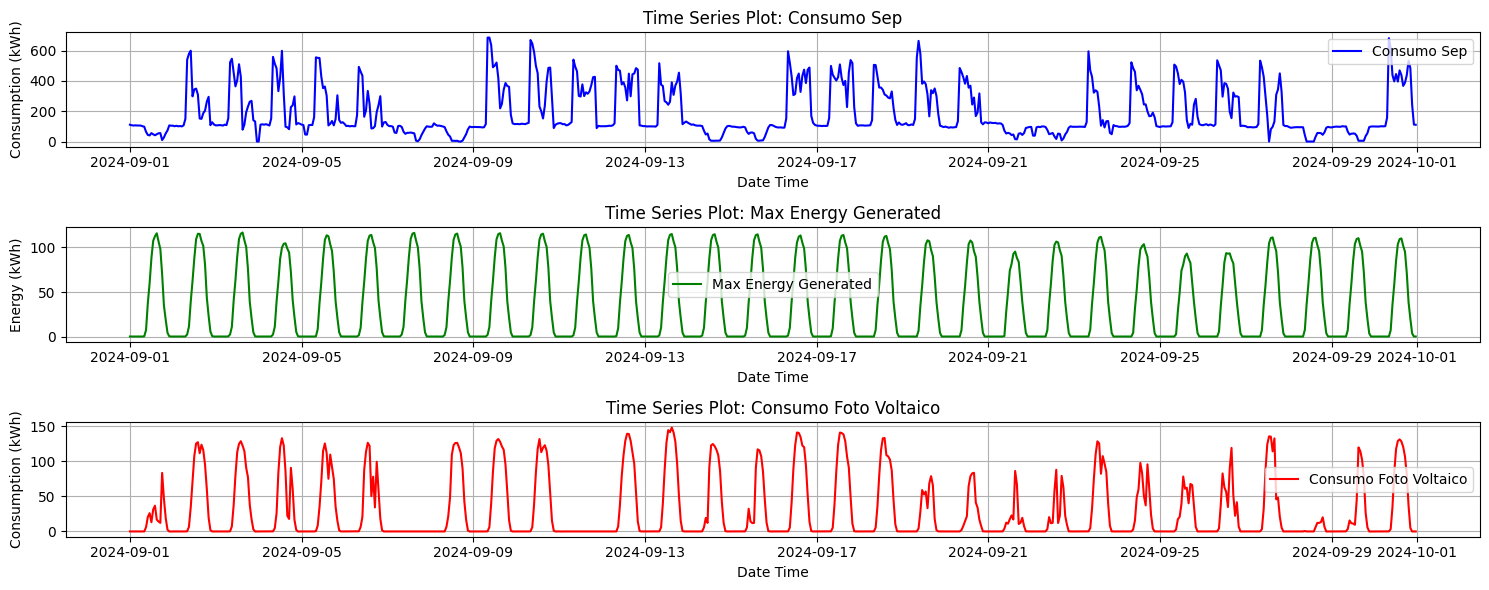

In [75]:
# Set the figure size
plt.figure(figsize=(15, 6))

# Plot 1: consumo_sep
plt.subplot(3, 1, 1)
plt.plot(final_df['date_time'], final_df['consumo_sep'], label='Consumo Sep', color='blue')
plt.title('Time Series Plot: Consumo Sep')
plt.xlabel('Date Time')
plt.ylabel('Consumption (kWh)')
plt.grid(True)
plt.legend()

# Plot 2: max energy generated
plt.subplot(3, 1, 2)
plt.plot(final_df['date_time'], final_df['max energy generated'], label='Max Energy Generated', color='green')
plt.title('Time Series Plot: Max Energy Generated')
plt.xlabel('Date Time')
plt.ylabel('Energy (kWh)')
plt.grid(True)
plt.legend()

# Plot 3: consumo_foto_voltaico
plt.subplot(3, 1, 3)
plt.plot(final_df['date_time'], final_df['consumo_foto_voltaico'], label='Consumo Foto Voltaico', color='red')
plt.title('Time Series Plot: Consumo Foto Voltaico')
plt.xlabel('Date Time')
plt.ylabel('Consumption (kWh)')
plt.grid(True)
plt.legend()

# Adjust layout
plt.tight_layout()
plt.show()

In [76]:
# Create the figure
fig = go.Figure()

# Add traces for each time series
fig.add_trace(go.Scatter(x=final_df['date_time'], y=final_df['consumo_sep'], mode='lines', name='Total Consumption', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=final_df['date_time'], y=final_df['max energy generated'], mode='lines', name='Max Energy Generated', line=dict(color='green')))
fig.add_trace(go.Scatter(x=final_df['date_time'], y=final_df['consumo_foto_voltaico'], mode='lines', name='Solar Consumption', line=dict(color='orange')))

# Update layout with labels, title, and grid
fig.update_layout(
    title='Time Series Plot of Energy Data',
    xaxis_title='Date Time',
    yaxis_title='Energy (kWh)',
    legend_title='Legend',
    template='plotly',
    xaxis=dict(tickangle=45),  # Rotate x-axis labels
    autosize=True
)

# Show the plot
fig.show()

In [77]:
final_df.head()

,date_time,consumo_sep,consumo_foto_voltaico,max energy generated
0,2024-09-01 00:00:00,110.855888,0.0,0.0
1,2024-09-01 01:00:00,107.341202,0.0,0.0
2,2024-09-01 02:00:00,105.550308,0.0,0.0
3,2024-09-01 03:00:00,106.840103,0.0,0.0
4,2024-09-01 04:00:00,105.879791,0.0,0.0


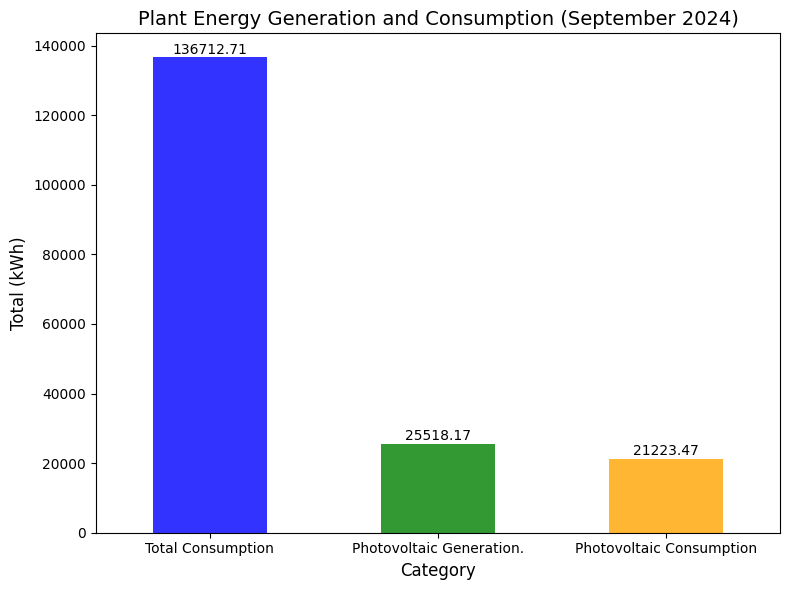

In [85]:
# Calculate the totals for the three columns
totals = final_df[['consumo_sep', 'max energy generated', 'consumo_foto_voltaico']].sum()

# Create a bar plot
plt.figure(figsize=(8, 6))
bars = totals.plot(kind='bar', color=['blue', 'green', 'orange'], alpha=0.8)

# Add labels and title
plt.title('Plant Energy Generation and Consumption (September 2024)', fontsize=14)
plt.ylabel('Total (kWh)', fontsize=12)
plt.xlabel('Category', fontsize=12)
plt.xticks(rotation=0)

labels = ['Total Consumption', 'Photovoltaic Generation.', 'Photovoltaic Consumption']
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=0)


# Annotate the bars with their values
for i, value in enumerate(totals):
    plt.text(i, value + 1000, f'{value:.2f}', ha='center', fontsize=10, color='black')

# Show the plot
plt.tight_layout()
plt.show()

### Feature Engineering

Here we add calculations required for battery optimization

In [86]:
final_df['balance'] = final_df['max energy generated'] - final_df['consumo_sep']

final_df.head(3)

,date_time,consumo_sep,consumo_foto_voltaico,max energy generated,balance
0,2024-09-01 00:00:00,110.855888,0.0,0.0,-110.855888
1,2024-09-01 01:00:00,107.341202,0.0,0.0,-107.341202
2,2024-09-01 02:00:00,105.550308,0.0,0.0,-105.550308


In [87]:
final_df['excess_energy'] = np.where(final_df['balance'] > 0, final_df['balance'], 0)

final_df['excess_energy'].sum()

np.float64(4966.587084256518)

In [88]:
df_day_1 = final_df[final_df['date_time'].dt.date == pd.to_datetime('2024-09-01').date()]

df_day_1.head(3)

,date_time,consumo_sep,consumo_foto_voltaico,max energy generated,balance,excess_energy
0,2024-09-01 00:00:00,110.855888,0.0,0.0,-110.855888,0.0
1,2024-09-01 01:00:00,107.341202,0.0,0.0,-107.341202,0.0
2,2024-09-01 02:00:00,105.550308,0.0,0.0,-105.550308,0.0


### Model for Battery Optimization

In [89]:
df_day_1 = final_df[final_df['date_time'].dt.date == pd.to_datetime('2024-09-01').date()]

# Create a new column 'charge' with initial values as 0
df_day_1['charge'] = 0

# Filter positive balances and calculate charges
positive_balances = df_day_1[df_day_1['balance'] > 0].copy()

# Ensure the sum of charges does not exceed 100
cumulative_charge = 0
for index, row in positive_balances.iterrows():
    max_allowed_charge = 100 - cumulative_charge
    charge_value = min(row['balance'], max_allowed_charge)  # Cap charge to remaining allowed sum
    positive_balances.at[index, 'charge'] = charge_value
    cumulative_charge += charge_value
    if cumulative_charge >= 100:
        break

# Update the original dataframe with the calculated charges
df_day_1.update(positive_balances[['charge']])

# Add a cumulative sum column for 'charge'
df_day_1['cumulative_charge'] = df_day_1['charge'].cumsum()

# Create the 'discharge' column
df_day_1['discharge'] = 0  # Initialize with 0
cumulative_charge_reached = df_day_1['cumulative_charge'] >= 100

# Assign absolute value of balance to 'discharge' where cumulative_charge >= 100 and balance is negative
cumulative_discharge = 0
for index, row in df_day_1.iterrows():
    if cumulative_charge_reached[index] and row['balance'] < 0:
        max_allowed_discharge = df_day_1['cumulative_charge'][index] - cumulative_discharge
        discharge_value = min(abs(row['balance']), max_allowed_discharge)
        df_day_1.at[index, 'discharge'] = discharge_value
        cumulative_discharge += discharge_value
        if cumulative_discharge >= df_day_1['cumulative_charge'][index]:
            break

# Initialize the starting value for battery status
initial_battery_status = 0  # Replace with the desired initial value if needed

# Calculate the battery status
df_day_1['battery_status'] = initial_battery_status + df_day_1['charge'].cumsum() - df_day_1['discharge'].cumsum()

# Display the updated dataframe

ra = (df_day_1['consumo_foto_voltaico'].sum() + df_day_1['discharge'].sum()) / df_day_1['max energy generated'].sum()

df_day_1.head()

C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\990951369.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\990951369.py:14: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '19.41855687586336' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\990951369.py:20: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         19.41855688
 32.2671543  

,date_time,consumo_sep,consumo_foto_voltaico,max energy generated,balance,excess_energy,charge,cumulative_charge,discharge,battery_status
0,2024-09-01 00:00:00,110.855888,0.0,0.0,-110.855888,0.0,0.0,0.0,0.0,0.0
1,2024-09-01 01:00:00,107.341202,0.0,0.0,-107.341202,0.0,0.0,0.0,0.0,0.0
2,2024-09-01 02:00:00,105.550308,0.0,0.0,-105.550308,0.0,0.0,0.0,0.0,0.0
3,2024-09-01 03:00:00,106.840103,0.0,0.0,-106.840103,0.0,0.0,0.0,0.0,0.0
4,2024-09-01 04:00:00,105.879791,0.0,0.0,-105.879791,0.0,0.0,0.0,0.0,0.0


### Determining charge and discharge time

It is a model that charges the battery once there is excess energy, and starts discharging once there is lack of energy in the system

In [90]:
# Extract the date from the datetime column
final_df['date'] = final_df['date_time'].dt.date

# Initialize an empty list to store results for each day
results = []

# Process each day separately
for day, df_day_1 in final_df.groupby('date'):
    df_day_1 = df_day_1.copy()

    # Create a new column 'charge' with initial values as 0
    df_day_1['charge'] = 0

    # Filter positive balances and calculate charges
    positive_balances = df_day_1[df_day_1['balance'] > 0].copy()

    # Ensure the sum of charges does not exceed 100
    cumulative_charge = 0
    for index, row in positive_balances.iterrows():
        max_allowed_charge = 100 - cumulative_charge
        charge_value = min(row['balance'], max_allowed_charge)  # Cap charge to remaining allowed sum
        positive_balances.at[index, 'charge'] = charge_value
        cumulative_charge += charge_value
        if cumulative_charge >= 100:
            break

    # Update the original dataframe with the calculated charges
    df_day_1.update(positive_balances[['charge']])

    # Add a cumulative sum column for 'charge'
    df_day_1['cumulative_charge'] = df_day_1['charge'].cumsum()

    # Create the 'discharge' column
    df_day_1['discharge'] = 0  # Initialize with 0
    cumulative_charge_reached = df_day_1['cumulative_charge'] >= 100

    # Assign absolute value of balance to 'discharge' where cumulative_charge >= 100 and balance is negative
    cumulative_discharge = 0
    for index, row in df_day_1.iterrows():
        if cumulative_charge_reached[index] and row['balance'] < 0:
            max_allowed_discharge = df_day_1['cumulative_charge'][index] - cumulative_discharge
            discharge_value = min(abs(row['balance']), max_allowed_discharge)
            df_day_1.at[index, 'discharge'] = discharge_value
            cumulative_discharge += discharge_value
            if cumulative_discharge >= df_day_1['cumulative_charge'][index]:
                break

    # Initialize the starting value for battery status
    initial_battery_status = 0  # Replace with the desired initial value if needed

    # Calculate the battery status
    df_day_1['battery_status'] = initial_battery_status + df_day_1['charge'].cumsum() - df_day_1['discharge'].cumsum()

    # **New Fix: Ensure full discharge at the last hour of the day**
    last_index = df_day_1.index[-1]
    remaining_battery = df_day_1.loc[last_index, 'battery_status']
    
    if remaining_battery > 0:
        df_day_1.at[last_index, 'discharge'] = remaining_battery
        df_day_1.at[last_index, 'battery_status'] = 0  # Reset for the next day

    # Append the processed day to the results list
    results.append(df_day_1)

# Combine all processed days into a single DataFrame
df_processed = pd.concat(results)

# Calculate the ratio (ra) for the entire month
ra = (df_processed['consumo_foto_voltaico'].sum() + df_processed['discharge'].sum()) / df_processed['max energy generated'].sum()

# Display the processed DataFrame and ratio
df_processed, ra


C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\703959741.py:22: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '19.41855687586336' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\703959741.py:28: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.         19.41855688
 32.2671543  48.31428882  0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.

C:\Users\Wambui\AppData\Local\Temp\ipykernel_27356\703959741.py:43: FutureWarning:

Setting an item of incompatible dtype is deprecated and wi

(              date_time  consumo_sep  consumo_foto_voltaico  \
 0   2024-09-01 00:00:00   110.855888                   0.00   
 1   2024-09-01 01:00:00   107.341202                   0.00   
 2   2024-09-01 02:00:00   105.550308                   0.00   
 3   2024-09-01 03:00:00   106.840103                   0.00   
 4   2024-09-01 04:00:00   105.879791                   0.00   
 ..                  ...          ...                    ...   
 715 2024-09-30 19:00:00   532.989990                  36.74   
 716 2024-09-30 20:00:00   484.213684                   4.98   
 717 2024-09-30 21:00:00   243.039886                  -0.04   
 718 2024-09-30 22:00:00   111.581192                   0.00   
 719 2024-09-30 23:00:00   110.579247                   0.00   
 
      max energy generated     balance  excess_energy        date  charge  \
 0                0.000000 -110.855888            0.0  2024-09-01     0.0   
 1                0.000000 -107.341202            0.0  2024-09-01     0.0   

In [91]:
print(ra)

0.8758802898203855


In [92]:
df_processed.to_excel('Processed_Charging_Battery.xlsx', index=False)

In [93]:
df_processed.head()

,date_time,consumo_sep,consumo_foto_voltaico,max energy generated,balance,excess_energy,date,charge,cumulative_charge,discharge,battery_status
0,2024-09-01 00:00:00,110.855888,0.0,0.0,-110.855888,0.0,2024-09-01,0.0,0.0,0.0,0.0
1,2024-09-01 01:00:00,107.341202,0.0,0.0,-107.341202,0.0,2024-09-01,0.0,0.0,0.0,0.0
2,2024-09-01 02:00:00,105.550308,0.0,0.0,-105.550308,0.0,2024-09-01,0.0,0.0,0.0,0.0
3,2024-09-01 03:00:00,106.840103,0.0,0.0,-106.840103,0.0,2024-09-01,0.0,0.0,0.0,0.0
4,2024-09-01 04:00:00,105.879791,0.0,0.0,-105.879791,0.0,2024-09-01,0.0,0.0,0.0,0.0


In [94]:
# Create the figure
fig = go.Figure()

# Add the battery_status time series trace
fig.add_trace(go.Scatter(
    x=df_processed['date_time'], 
    y=df_processed['battery_status'], 
    mode='lines', 
    name='Battery Status', 
    line=dict(color='blue')
))

# Update layout with labels, title, and grid
fig.update_layout(
    title='Time Series Plot: Battery Charging and Discharging Status',
    xaxis_title='Date Time',
    yaxis_title='Battery Status',
    legend_title='Legend',
    template='plotly',
    xaxis=dict(tickangle=45), 
    autosize=True
)

# Show the plot
fig.show()

### Conclusion on Battery Optimization

The model results show that the battery doesn’t need daily charging/discharging, as energy demand varies with occasional consumption spikes. Typically, the battery charges around midday and discharges in the evening, aligning with Spain’s solar patterns in September. This strategy achieved a **high Self-Consumption Ratio of 0.8757**, reflecting efficient solar energy use.

# Objective 3: Environmental Impact Analysis

In [95]:
# Load factory electricity consumption data
consumo_full = pd.concat([
    pd.read_csv("data/repsol_data/Consumo.csv", parse_dates=["FECHA"]),
    pd.read_csv("data/repsol_data/Consumo_sept.csv", parse_dates=["FECHA"])
])
consumo_full['FECHA'] = pd.to_datetime(consumo_full['FECHA'])
consumo_full.set_index('FECHA', inplace=True)

# Load CO₂ intensity data and merge 2023 + 2024 files
co2_intensity = pd.concat([
    pd.read_csv("data/repsol_data/ES_2023_hourly.csv", parse_dates=["Datetime (UTC)"]),
    pd.read_csv("data/repsol_data/ES_2024_hourly.csv", parse_dates=["Datetime (UTC)"])
])
co2_intensity["Datetime (UTC)"] = pd.to_datetime(co2_intensity["Datetime (UTC)"])
co2_intensity.set_index('Datetime (UTC)', inplace=True)

In [96]:
consumo_full.head(2)

,TOTAL_KWH_ENERGIA
FECHA,
2023-07-24 11:00:00,506.012634
2023-07-24 12:00:00,456.551453


In [97]:
co2_intensity.head(2)

,Country,Zone Name,Zone Id,Carbon Intensity gCO₂eq/kWh (direct),Carbon Intensity gCO₂eq/kWh (LCA),Low Carbon Percentage,Renewable Percentage,Data Source,Data Estimated,Data Estimation Method
Datetime (UTC),,,,,,,,,,
2023-01-01 00:00:00,Spain,Spain,ES,79.49,110.37,84.15,50.75,entsoe.eu,False,NaN
2023-01-01 01:00:00,Spain,Spain,ES,82.59,113.77,83.73,49.24,entsoe.eu,False,NaN


In [98]:
co2_intensity = co2_intensity[['Carbon Intensity gCO₂eq/kWh (direct)', 'Carbon Intensity gCO₂eq/kWh (LCA)']]
co2_intensity.head(2)

,Carbon Intensity gCO₂eq/kWh (direct),Carbon Intensity gCO₂eq/kWh (LCA)
Datetime (UTC),,
2023-01-01 00:00:00,79.49,110.37
2023-01-01 01:00:00,82.59,113.77


In [99]:
final_df = pd.merge(consumo_full, co2_intensity, left_index=True, right_index=True)

# filtering only for september 2024 

final_df = final_df[(final_df.index.year == 2024) & (final_df.index.month == 9)]
final_df.head()


,TOTAL_KWH_ENERGIA,Carbon Intensity gCO₂eq/kWh (direct),Carbon Intensity gCO₂eq/kWh (LCA)
2024-09-01 00:00:00,110.855888,170.04,226.11
2024-09-01 01:00:00,107.341202,175.13,232.36
2024-09-01 02:00:00,105.550308,175.53,233.21
2024-09-01 03:00:00,106.840103,174.22,231.58
2024-09-01 04:00:00,105.879791,175.05,232.53


In [100]:
# Rename for clarity
final_df.rename(columns={
    "TOTAL_KWH_ENERGIA": "Grid_Consumption_Before",  
    "Carbon Intensity gCO₂eq/kWh (direct)": "CO2_Intensity" 
}, inplace=True)

final_df.drop(columns='Carbon Intensity gCO₂eq/kWh (LCA)', inplace=True)  
final_df.head(2)


,Grid_Consumption_Before,CO2_Intensity
2024-09-01 00:00:00,110.855888,170.04
2024-09-01 01:00:00,107.341202,175.13


In [101]:
# Compute baseline CO₂ emissions
final_df["CO2_Emitted_Before"] = final_df["Grid_Consumption_Before"] * final_df["CO2_Intensity"]
final_df.head(2)

,Grid_Consumption_Before,CO2_Intensity,CO2_Emitted_Before
2024-09-01 00:00:00,110.855888,170.04,18849.935258
2024-09-01 01:00:00,107.341202,175.13,18798.664668


In [102]:
## from objective 2, change all the columns we need to find the actual co2 saved for the objective 3

df_from_obj_2 = pd.read_excel('Processed_Charging_Battery.xlsx')
df_from_obj_2.set_index('date_time', inplace=True)
df_from_obj_2.head(3)


,consumo_sep,consumo_foto_voltaico,max energy generated,balance,excess_energy,date,charge,cumulative_charge,discharge,battery_status
date_time,,,,,,,,,,
2024-09-01 00:00:00,110.855888,0.0,0.0,-110.855888,0.0,2024-09-01,0.0,0.0,0.0,0.0
2024-09-01 01:00:00,107.341202,0.0,0.0,-107.341202,0.0,2024-09-01,0.0,0.0,0.0,0.0
2024-09-01 02:00:00,105.550308,0.0,0.0,-105.550308,0.0,2024-09-01,0.0,0.0,0.0,0.0


In [103]:
# adding the predicted max solar energy, charge and discharge schedules from the objective 2 dataframe

final_df["Solar_Generation_Potential"] = df_from_obj_2['max energy generated']
final_df["Battery_Charge"] = df_from_obj_2['charge']
final_df["Battery_Discharge"] = df_from_obj_2['discharge']

final_df.head(3)

,Grid_Consumption_Before,CO2_Intensity,CO2_Emitted_Before,Solar_Generation_Potential,Battery_Charge,Battery_Discharge
2024-09-01 00:00:00,110.855888,170.04,18849.935258,0.0,0.0,0.0
2024-09-01 01:00:00,107.341202,175.13,18798.664668,0.0,0.0,0.0
2024-09-01 02:00:00,105.550308,175.53,18527.245603,0.0,0.0,0.0


In [104]:
# Compute expected Grid Consumption after optimization

final_df["Grid_Consumption_After"] = final_df["Grid_Consumption_Before"] - final_df["Battery_Discharge"]

final_df.head()

,Grid_Consumption_Before,CO2_Intensity,CO2_Emitted_Before,Solar_Generation_Potential,Battery_Charge,Battery_Discharge,Grid_Consumption_After
2024-09-01 00:00:00,110.855888,170.04,18849.935258,0.0,0.0,0.0,110.855888
2024-09-01 01:00:00,107.341202,175.13,18798.664668,0.0,0.0,0.0,107.341202
2024-09-01 02:00:00,105.550308,175.53,18527.245603,0.0,0.0,0.0,105.550308
2024-09-01 03:00:00,106.840103,174.22,18613.682771,0.0,0.0,0.0,106.840103
2024-09-01 04:00:00,105.879791,175.05,18534.257460,0.0,0.0,0.0,105.879791


In [105]:
# check that actually we are reducing consumption from grid compared to before

final_df[final_df['Grid_Consumption_After'] < final_df['Grid_Consumption_Before']].head()

,Grid_Consumption_Before,CO2_Intensity,CO2_Emitted_Before,Solar_Generation_Potential,Battery_Charge,Battery_Discharge,Grid_Consumption_After
2024-09-01 20:00:00,53.621025,175.76,9424.431369,18.765885,0.0,34.855140,18.765885
2024-09-01 21:00:00,73.342941,168.76,12377.354771,4.151501,0.0,65.144860,8.198081
2024-09-04 23:00:00,117.448906,119.77,14066.855465,0.000000,0.0,24.913808,92.535098
2024-09-05 23:00:00,127.183411,114.59,14573.947026,0.000000,0.0,6.288758,120.894653
2024-09-06 23:00:00,128.710449,116.45,14988.331812,0.000000,0.0,45.814153,82.896296


In [106]:
# Compute optimized CO₂ emissions
final_df["CO2_Emitted_After"] = final_df["Grid_Consumption_After"] * final_df["CO2_Intensity"]

# Compute CO₂ saved
final_df["CO2_Saved"] = final_df["CO2_Emitted_Before"] - final_df["CO2_Emitted_After"]

# Display summary results
total_co2_saved = final_df["CO2_Saved"].sum()
percentage_co2_saved = (total_co2_saved / final_df["CO2_Emitted_Before"].sum()) * 100
print(f"Total CO₂ Emissions Avoided in September 2024: {total_co2_saved:.4f} gCO₂")
print(f"Percentage of CO₂ Emissions avoided in September 2024: {percentage_co2_saved:.4f} % gCO₂")
final_df.head(3)

Total CO₂ Emissions Avoided in September 2024: 123267.4148 gCO₂
Percentage of CO₂ Emissions avoided in September 2024: 1.0636 % gCO₂


,Grid_Consumption_Before,CO2_Intensity,CO2_Emitted_Before,Solar_Generation_Potential,Battery_Charge,Battery_Discharge,Grid_Consumption_After,CO2_Emitted_After,CO2_Saved
2024-09-01 00:00:00,110.855888,170.04,18849.935258,0.0,0.0,0.0,110.855888,18849.935258,0.0
2024-09-01 01:00:00,107.341202,175.13,18798.664668,0.0,0.0,0.0,107.341202,18798.664668,0.0
2024-09-01 02:00:00,105.550308,175.53,18527.245603,0.0,0.0,0.0,105.550308,18527.245603,0.0


In [107]:
final_df[['CO2_Saved']]

,CO2_Saved
2024-09-01 00:00:00,0.0
2024-09-01 01:00:00,0.0
2024-09-01 02:00:00,0.0
2024-09-01 03:00:00,0.0
2024-09-01 04:00:00,0.0
...,...
2024-09-30 19:00:00,0.0
2024-09-30 20:00:00,0.0
2024-09-30 21:00:00,0.0
2024-09-30 22:00:00,0.0


In [108]:
# Rename the column and reset the index
final_df_to_save = final_df[['CO2_Saved']].rename(columns={'CO2_Saved': 'CO2_Avoided'}).reset_index()

# Save to CSV with the index as a datetime column
final_df_to_save.rename(columns={'Datetime': 'Datetime'}).to_csv('fura_co2_avoided.csv', index=False)

### Findings on CO2 Emmisions

* Total CO₂ Emissions Avoided in September 2024: 123267.4148 gCO₂
* Percentage of CO₂ Emissions avoided in September 2024: 1.0636 % gCO₂